In [12]:
import nbformat
from nbconvert import HTMLExporter

# Leer el notebook
with open('C:\\Users\\Usuario\\Documents\\Github\\Talvi\\notebooks\\vulnerabilidad-externa-vecm chile.ipynb', 'r') as f:
    notebook = nbformat.read(f, as_version=4)

# Convertir a HTML
html_exporter = HTMLExporter()
(body, resources) = html_exporter.from_notebook_node(notebook)

# Guardar el HTML
with open('v6.html', 'w') as f:
    f.write(body)

# Indicador de Vulnerabilidad Externa (IVE) — Construcción del índice

**Autores:** Manuel Alejandro Hidalgo Pérez; Ernesto Talvi  
**Proyecto:** Indicador vulnerabilidad Latinoamérica  
**Fecha:** 8 de octubre de 2025  
**Versión del cuaderno:** v0.9  
**Licencia:** © 2025 Manuel Alejandro Hidalgo Pérez y Ernesto Talvi. Todos los derechos reservados.  
<!-- Cambia esta línea si prefieres CC BY-NC 4.0 u otra licencia. -->

---

## Propósito
Este cuaderno construye el **Índice de Vulnerabilidad Externa (IVE)** a partir de un modelo de corrección de errores (ECM) con cointegración, combinando:
1) desequilibrio de largo plazo (|ECT| normalizado), y  
2) volatilidad de corto plazo (σ móvil de residuos),  
para señalizar riesgo macro a 1–2 trimestres y generar **figuras** y **CSV** reproducibles.

## Flujo (pipeline)
**Datos** → **Tests de integración/cointegración** → **ECM** → **IRFs** → **Σ<sub>t</sub> (volatilidad)** → **μ<sub>t</sub>, σ<sub>t</sub>** → **Índice IVE** → **Figuras/CSV**.

## Parámetros clave (por defecto)
- Horizonte de choque: `H = 4` trimestres  
- Ventana de volatilidad: `WINDOW_SIGMA = 40` períodos  
- Elasticidad de penalización por riesgo: `LAMBDA = 1.0`  
- Ventana COVID (exclusión opcional): `2020-03-01` a `2021-06-30`  
*(Estos valores pueden redefinirse en el bloque `CONFIG`.)*

## Cómo usar este cuaderno
1. Verifica/ajusta rutas y `CONFIG` al inicio.  
2. Ejecuta todo (Kernel → Restart & Run All).  
3. Revisa salidas en `figures/` y CSVs asociados.

## Salidas esperadas
- Gráficos: `figures/vulnerability_*.pdf` (y opcional `.png`)  
- Tablas/CSV: índice y métricas resumen para validación/backtesting

## Requisitos
Python ≥ 3.10 | `pandas`, `numpy`, `statsmodels`, `matplotlib`  
*(Si usas entornos, documenta el `requirements.txt` o `environment.yml`.)*

> **Nota:** Este IVE complementa el análisis macro-financiero; no lo sustituye. Interpretar junto con información doméstica y de estabilidad financiera.


In [33]:
# ==============================================================================
# FASE 1: CONFIGURACIÓN, CARGA Y PREPARACIÓN DE DATOS (VERSIÓN GENERALIZADA)
# ==============================================================================

# --- 1. IMPORTACIÓN DE LIBRERÍAS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

warnings.filterwarnings("ignore", message="Non-invertible starting MA.*")
warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency")


# ==============================================================================
# --- 2. CONFIG GENERAL POR PAÍS ---
# ==============================================================================

COUNTRY = "brazil"                # 🔥 SOLO CAMBIAS ESTA LÍNEA: "chile" o "brazil"

COUNTRY_CONFIG = {
    "chile": {
        "gdp_file": "../data/QGDP/chile.csv",
        "gdp_raw_col": None,      # lo detectamos automáticamente
        "gdp_final_name": "GDP_CHILE",
        "log_gdp_col": "log_gdp_chile",
        "tot_file": "../data/indicadores/monthly_results_chile.csv",
        "tot_col_raw": "ctot_level",
        "tot_final_name": "termoftrade",
        "log_tot_col": "log_tot_chile",
        "ip_log_col": "log_ip_g7"      # 🔹 NUEVO: nombre estándar del índice ponderado
    },
    "brazil": {
        "gdp_file": "../data/QGDP/brazil.csv",
        "gdp_raw_col": None,
        "gdp_final_name": "GDP_BRAZIL",
        "log_gdp_col": "log_gdp_brazil",
        "tot_file": "../data/indicadores/monthly_results_brazil.csv",
        "tot_col_raw": "ctot_level",
        "tot_final_name": "termoftrade",
        "log_tot_col": "log_tot_brazil",
        "ip_log_col": "log_ip_g7"      # 🔹 Igual nombre, pesos distintos
    }
}


cfg = COUNTRY_CONFIG[COUNTRY]


# ==============================================================================
# --- 3. CARGA Y PROCESAMIENTO INICIAL ---
# ==============================================================================

# --- Indicadores macro mensuales (comunes a ambos países) ---
df_indicadores = pd.read_csv('../data/indicadores/indicadores_macroeconomicos.csv',
                             sep=';', encoding='latin1')

df_indicadores = df_indicadores.set_index('fecha')
df_indicadores.index = df_indicadores.index.astype(str)
df_indicadores.index.name = 'fecha'


# --- Términos de intercambio específicos del país ---
df_termotrade = pd.read_csv(cfg["tot_file"], sep=";", encoding='latin1')
df_termotrade = df_termotrade[['date', cfg["tot_col_raw"]]]
df_termotrade = df_termotrade.rename(columns={cfg["tot_col_raw"]: cfg["tot_final_name"]})

df_termotrade = df_termotrade.set_index('date')
df_termotrade.index = pd.to_datetime(df_termotrade.index).strftime('%Y%m')
df_termotrade.index.name = 'fecha'


# --- PIB trimestral específico del país ---
df_gdp = pd.read_csv(cfg["gdp_file"], sep=",", encoding='latin1')
df_gdp = df_gdp.set_index(df_gdp.columns[0])
df_gdp.index = pd.to_datetime(df_gdp.index.astype(str)).strftime('%Y%m')

# Detectar columna de PIB automáticamente
if cfg["gdp_raw_col"] is None:
    gdp_col = df_gdp.columns[0]
else:
    gdp_col = cfg["gdp_raw_col"]

df_gdp = df_gdp.rename(columns={gdp_col: cfg["gdp_final_name"]})


# ==============================================================================
# --- 4. CONSOLIDACIÓN DE DATOS MENSUALES ---
# ==============================================================================

df_monthly = df_indicadores.join(df_termotrade, how='outer')

# Dummy COVID
df_monthly['pandemia_dummy'] = 0
df_monthly.loc['202003':'202009', 'pandemia_dummy'] = 1


# ==============================================================================
# --- 5. ALINEACIÓN A TRIMESTRAL ---
# ==============================================================================

print("="*50)
print(f"🔧 ALINEANDO DATOS ({COUNTRY.upper()}) A FRECUENCIA TRIMESTRAL")
print("="*50)

df_gdp.index = pd.to_datetime(df_gdp.index, format='%Y%m')
df_monthly.index = pd.to_datetime(df_monthly.index, format='%Y%m')

# Resample mensual → trimestral
df_monthly_quarterly = df_monthly.drop(columns=['pandemia_dummy']).resample('Q').mean()
df_dummy_quarterly = df_monthly[['pandemia_dummy']].resample('Q').max()

df_monthly_agg = df_monthly_quarterly.join(df_dummy_quarterly)

# Índices al inicio del trimestre
df_gdp.index = df_gdp.index.to_period('Q').start_time
df_monthly_agg.index = df_monthly_agg.index.to_period('Q').start_time

print("✅ Datos alineados correctamente.")


# ==============================================================================
# --- 6. CREACIÓN DE DF_FINAL: df_aligned ---
# ==============================================================================

df_aligned = df_gdp.join(df_monthly_agg, how='inner')
df_aligned.dropna(inplace=True)

# Logs automáticos (nombres dependientes del país)
df_aligned[cfg["log_gdp_col"]] = np.log(df_aligned[cfg["gdp_final_name"]])
df_aligned[cfg["log_tot_col"]] = np.log(df_aligned[cfg["tot_final_name"]])

# Variables financieras
df_aligned['us_10y'] = df_aligned['DGS10']
df_aligned['risk_spread'] = df_aligned['SPREAD_USA']

# Reordenar columnas
main_vars = [cfg["gdp_final_name"], cfg["log_gdp_col"]]
other_vars = [c for c in df_aligned.columns if c not in main_vars]
df_aligned = df_aligned[main_vars + other_vars]


# ==============================================================================
# --- 7. RESUMEN FINAL ---
# ==============================================================================

print(f"\n📊 DATOS FINALES ({COUNTRY.upper()}) ALINEADOS:")
print(f"   Observaciones: {len(df_aligned)}")
if not df_aligned.empty:
    print(f"   Período: {df_aligned.index.min().strftime('%Y-%m-%d')} → {df_aligned.index.max().strftime('%Y-%m-%d')}")
else:
    print("⚠️ El DataFrame está vacío. Revisa las fechas.")

display(df_aligned.head())


🔧 ALINEANDO DATOS (BRAZIL) A FRECUENCIA TRIMESTRAL
✅ Datos alineados correctamente.

📊 DATOS FINALES (BRAZIL) ALINEADOS:
   Observaciones: 100
   Período: 2000-01-01 → 2024-10-01


,GDP_BRAZIL,log_gdp_brazil,PI_USA,PI_FRA,PI_GER,PI_ITA,PI_UK,DGS10,SPREAD_USA,termoftrade,pandemia_dummy,log_tot_brazil,us_10y,risk_spread
2000-01-01,192382.2,12.167239,91.738900,109.200000,83.066667,119.500000,76.533333,6.479007,5.018454,99.923617,0,4.604406,6.479007,5.018454
2000-04-01,194948.4,12.180490,92.867467,110.933333,85.300000,121.700000,77.433333,6.176085,5.960372,99.878941,0,4.603959,6.176085,5.960372
2000-07-01,197616.2,12.194082,92.803667,111.100000,86.766667,121.633333,78.133333,5.893029,6.312758,99.783583,0,4.603004,5.893029,6.312758
2000-10-01,199860.6,12.205375,92.548700,112.500000,87.100000,123.966667,79.700000,5.565405,8.132197,99.716377,0,4.602330,5.565405,8.132197
2001-01-01,200333.4,12.207738,91.411467,113.166667,87.500000,121.766667,80.400000,5.048451,8.006848,99.756358,0,4.602731,5.048451,8.006848


# Creo indicador industrial endógeno buscando pesos que maximice la correlación con GDP

📊 Matriz de correlaciones (tasas de crecimiento logarítmicas) — BRAZIL:


,d_PI_USA,d_PI_FRA,d_PI_GER,d_PI_ITA,d_PI_UK,d_log_gdp_brazil
d_PI_USA,1.000000,0.883625,0.876022,0.845928,0.769587,0.776292
d_PI_FRA,0.883625,1.000000,0.881475,0.925222,0.848340,0.800802
d_PI_GER,0.876022,0.881475,1.000000,0.837460,0.783795,0.784916
d_PI_ITA,0.845928,0.925222,0.837460,1.000000,0.802446,0.732792
d_PI_UK,0.769587,0.848340,0.783795,0.802446,1.000000,0.708053
d_log_gdp_brazil,0.776292,0.800802,0.784916,0.732792,0.708053,1.000000


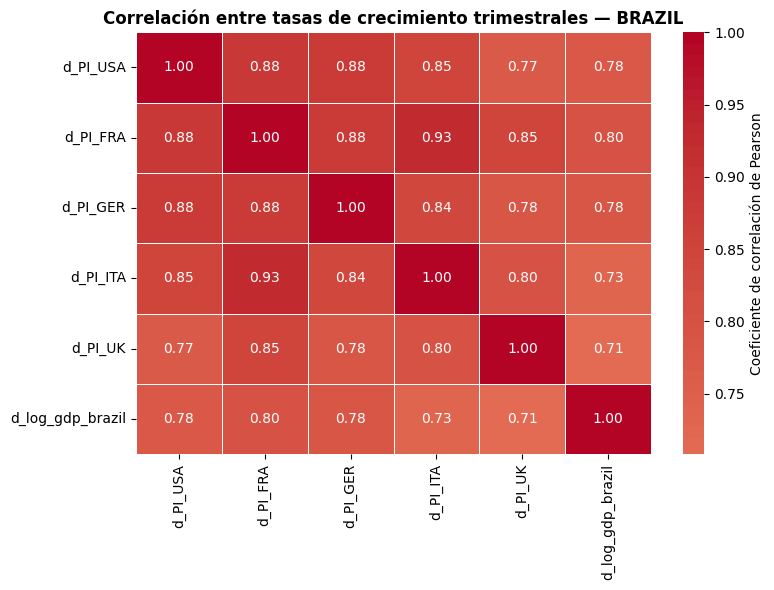

🔹 Correlación de crecimiento de log_gdp_brazil con cada IPI — BRAZIL:


d_PI_FRA    0.800802
d_PI_GER    0.784916
d_PI_USA    0.776292
d_PI_ITA    0.732792
d_PI_UK     0.708053
Name: d_log_gdp_brazil, dtype: float64

In [34]:
# ==============================================================================
# FASE X: CORRELACIONES ENTRE CRECIMIENTOS (IPI G7 + PIB)
#   (VERSIÓN GENERALIZADA POR PAÍS)
# ==============================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Seleccionar variables relevantes según el país ---
cfg = COUNTRY_CONFIG[COUNTRY]

vars_ip = ['PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK']   # comunes a ambos países
var_gdp = cfg["log_gdp_col"]                                  # puede ser log_gdp_chile o log_gdp_brazil

vars_pi = vars_ip + [var_gdp]                                  # paquete final de variables


# --- 2. Subconjunto del dataframe ---
df_growth = df_aligned[vars_pi].copy()


# --- 3. Calcular tasas de crecimiento trimestrales (log-diferencia) ---
for col in df_growth.columns:
    df_growth[f'd_{col}'] = np.log(df_growth[col]).diff()

# Mantener solo las columnas de crecimiento
growth_cols = [f'd_{col}' for col in vars_pi]
df_growth = df_growth[growth_cols].dropna()


# --- 4. Calcular matriz de correlaciones ---
corr_matrix_growth = df_growth.corr()

print(f"📊 Matriz de correlaciones (tasas de crecimiento logarítmicas) — {COUNTRY.upper()}:")
display(corr_matrix_growth)


# --- 5. Heatmap de correlación ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_growth,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de correlación de Pearson'}
)
plt.title(f'Correlación entre tasas de crecimiento trimestrales — {COUNTRY.upper()}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# --- 6. Correlación individual con el PIB (generalizado) ---
col_gdp_growth = f'd_{var_gdp}'   # puede ser d_log_gdp_chile o d_log_gdp_brazil

corr_with_gdp = corr_matrix_growth[col_gdp_growth].drop(col_gdp_growth).sort_values(ascending=False)

print(f"🔹 Correlación de crecimiento de {var_gdp} con cada IPI — {COUNTRY.upper()}:")
display(corr_with_gdp)


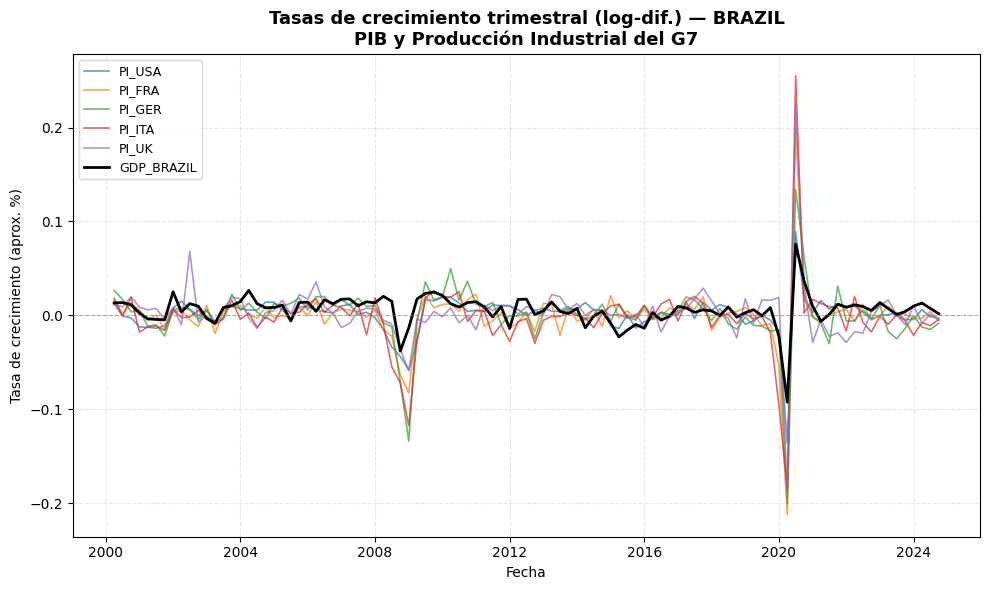

In [35]:
# ==============================================================================
# FASE X: GRÁFICO DE TASAS DE CRECIMIENTO (IPI G7 + PIB)
#   (VERSIÓN GENERALIZADA POR PAÍS)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Configuración de variables según el país ---
cfg = COUNTRY_CONFIG[COUNTRY]

vars_ip = ['PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK']  # siempre iguales
var_gdp_raw = cfg['gdp_final_name']                          # GDP_CHILE o GDP_BRAZIL

# Título automático
country_label = COUNTRY.upper()

# --- 2. Calcular tasas de crecimiento logarítmicas ---
df_growth = df_aligned[vars_ip + [var_gdp_raw]].copy()
df_growth = np.log(df_growth).diff().dropna()

# --- 3. Crear el gráfico ---
plt.figure(figsize=(10, 6))

# Series IPI (suaves)
for col in vars_ip:
    plt.plot(df_growth.index, df_growth[col],
             label=col, alpha=0.7, linewidth=1.2)

# PIB (destacado)
plt.plot(df_growth.index, df_growth[var_gdp_raw],
         color='black', linewidth=2.0, label=var_gdp_raw)

# --- 4. Personalización del gráfico ---
plt.title(f'Tasas de crecimiento trimestral (log-dif.) — {country_label}\n'
          f'PIB y Producción Industrial del G7',
          fontsize=13, fontweight='bold')

plt.xlabel('Fecha')
plt.ylabel('Tasa de crecimiento (aprox. %)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()


📊 Pesos óptimos para maximizar la correlación con el crecimiento del PIB de BRAZIL:


,País,Peso óptimo
0,PI_USA,0.315
1,PI_FRA,0.360
2,PI_GER,0.270
3,PI_ITA,0.000
4,PI_UK,0.055


🔹 Correlación máxima alcanzada: 0.823


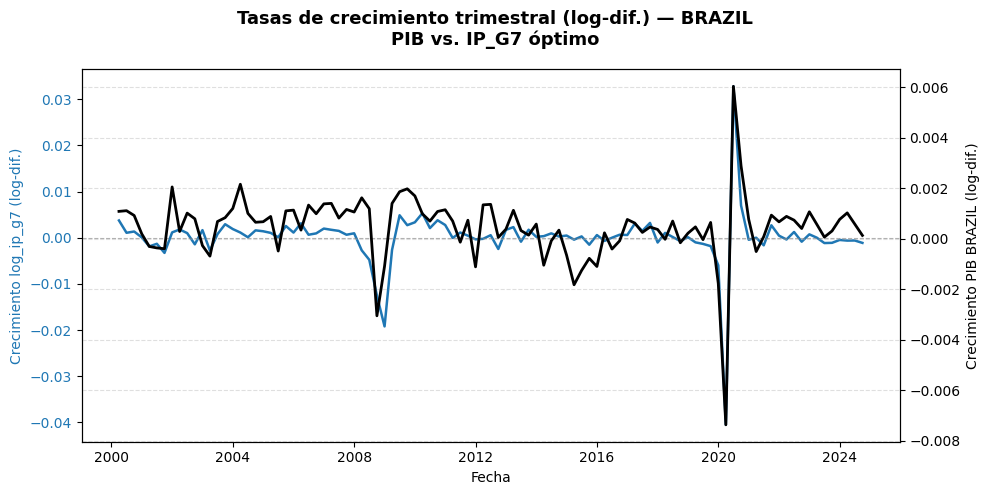

📈 Correlación entre crecimiento del IP_G7 óptimo y PIB de BRAZIL: 0.822


In [36]:
# ==============================================================================
# FASE X: CONSTRUCCIÓN DEL ÍNDICE IP_G7 ÓPTIMO (VERSIÓN GENERALIZADA)
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- 1. Variables relevantes ---
cfg = COUNTRY_CONFIG[COUNTRY]

vars_pi = ['PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK']
var_gdp = cfg['log_gdp_col']                 # log_gdp_chile o log_gdp_brazil
country_label = COUNTRY.upper()


# --- 2. Subconjunto del DataFrame ---
df_corr = df_aligned[vars_pi + [var_gdp]].dropna()

# --- 3. Tasas de crecimiento (log-diferencias) ---
df_growth = np.log(df_corr).diff().dropna()


# --- 4. Función objetivo: maximizar correlación ---
def objective(weights):
    ip_g7_weighted = np.dot(df_growth[vars_pi].values, weights)
    corr = np.corrcoef(ip_g7_weighted, df_growth[var_gdp].values)[0, 1]
    return -corr  # negativo porque minimize minimiza


# --- 5. Restricciones ---
cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * len(vars_pi)
w0 = np.ones(len(vars_pi)) / len(vars_pi)

# --- 6. Optimización ---
result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=cons)
opt_weights = result.x
opt_corr = -result.fun


# --- 7. Resultados ---
weights_table = pd.DataFrame({'País': vars_pi, 'Peso óptimo': opt_weights})
print(f"📊 Pesos óptimos para maximizar la correlación con el crecimiento del PIB de {country_label}:")
display(weights_table.style.format({'Peso óptimo': '{:.3f}'}))
print(f"🔹 Correlación máxima alcanzada: {opt_corr:.3f}")


# --- 8. Crear el índice ponderado y calcular tasas de crecimiento ---
df_aligned[cfg['ip_log_col']] = np.log(np.dot(df_aligned[vars_pi], opt_weights))
df_plot = np.log(df_aligned[[cfg['ip_log_col'], var_gdp]]).diff().dropna()


# --- 9. Visualización con doble eje Y ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje izquierdo → log_ip_g7
ax1.plot(df_plot.index, df_plot[cfg['ip_log_col']],
         color='tab:blue', linewidth=1.8, label='Crecimiento log_ip_g7')
ax1.set_ylabel('Crecimiento log_ip_g7 (log-dif.)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Eje derecho → PIB
ax2 = ax1.twinx()
ax2.plot(df_plot.index, df_plot[var_gdp],
         color='black', linewidth=2.0, label=f'Crecimiento PIB {country_label} (log-dif.)')
ax2.set_ylabel(f'Crecimiento PIB {country_label} (log-dif.)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Títulos y formato
fig.suptitle(f'Tasas de crecimiento trimestral (log-dif.) — {country_label}\n'
             f'PIB vs. IP_G7 óptimo',
             fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


# --- 10. Correlación final ---
corr_final = df_plot.corr().iloc[0, 1]
print(f"📈 Correlación entre crecimiento del IP_G7 óptimo y PIB de {country_label}: {corr_final:.3f}")


## FASE 2 · Diagnóstico temporal: ADF, KPSS y Johansen

**Objetivo.** Clasificar cada serie como **I(0)** o **I(1)** y, si hay ≥2 variables I(1), estimar el **rango de cointegración** con Johansen para justificar el uso de un ECM/VECM.

**Qué hace esta celda.**
1) Ejecuta **ADF** (H₀: raíz unitaria) y **KPSS** (H₀: estacionaria) sobre cada variable clave.  
2) Aplica una **regla de decisión**: se etiqueta **I(1)** si `p_ADF > 0.05` **y** `p_KPSS < 0.05`.  
   *Si KPSS devuelve `InterpolationWarning` o falla (series muy persistentes), se confía en ADF para decidir.*  
3) Construye la lista `i1_variables` y corre **Johansen (traza)** con `det_order=1` y `k_ar_diff=2`.  
4) Reporta el número de **relaciones de cointegración** `r`.

**Salidas esperadas.**
- Tabla `summary_table` con p-valores ADF/KPSS y conclusión I(0)/I(1).  
- Lista `i1_variables`.  
- Tabla/print del **test de la traza** (estadístico vs. valor crítico 5%) y veredicto `r`.

**Interpretación rápida (con tus resultados actuales).**
- I(1): `log_gdp_brazil`, `log_tot_brazil`, `us_10y`.  
- Johansen (traza) ⇒ **r = 1**. Procede ECM con un vector de cointegración.

**Precauciones.**
- Asegura frecuencia/fechas alineadas (`df_aligned`).  
- Los **warnings KPSS** indican p-valores límite (menores que la tabla); no invalidan el diagnóstico si ADF y KPSS son consistentes.

**Próximo paso.** Usar `r=1` para construir el **ECT** e ir a la estimación del **ECM** (Fase 3).


In [37]:
# ==============================================================================
# FASE 2: DIAGNÓSTICO DE PROPIEDADES TEMPORALES Y BÚSQUEDA DE COINTEGRACIÓN
# ==============================================================================

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
import pandas as pd
import numpy as np
from itertools import combinations

# ==============================================================================
# 0. CONSTRUCCIÓN DEL SET DE VARIABLES SEGÚN EL PAÍS
# ==============================================================================

cfg = COUNTRY_CONFIG[COUNTRY]

# Variables “principales” del modelo estructural
variables_to_test = [
    cfg['log_gdp_col'],     # log_gdp_chile o log_gdp_brazil
    cfg['ip_log_col'],      # log_ip_g7 (país-dependiente por pesos)
    cfg['log_tot_col'],     # log_tot_chile o log_tot_brazil
    'us_10y',
    'risk_spread'
]

# Solo las que existan en df_aligned
variables_to_test = [v for v in variables_to_test if v in df_aligned.columns]

# ==============================================================================
# 1. TESTS DE RAÍZ UNITARIA (ADF + KPSS)
# ==============================================================================

def test_unit_root_summary(series, name):
    """
    Ejecuta ADF + KPSS y clasifica la serie como I(0) o I(1).
    Criterio: I(1) si ADF no rechaza raíz unitaria y KPSS rechaza estacionariedad.
    """
    results = {'Variable': name}

    # ADF: H0 = raíz unitaria
    adf_test = adfuller(series.dropna(), regression='c', autolag='AIC')
    results['ADF_p_value'] = adf_test[1]

    # KPSS: H0 = estacionaria
    try:
        kpss_test = kpss(series.dropna(), regression='c', nlags='auto')
        results['KPSS_p_value'] = kpss_test[1]
    except Exception:
        results['KPSS_p_value'] = None

    is_i1 = False
    if results['ADF_p_value'] > 0.05:
        if results['KPSS_p_value'] is not None and results['KPSS_p_value'] < 0.05:
            is_i1 = True
        elif results['KPSS_p_value'] is None:
            is_i1 = True

    results['Conclusion'] = 'I(1)' if is_i1 else 'I(0)'
    return results

print("="*60)
print(f"📊 1. ANÁLISIS DE RAÍZ UNITARIA — {COUNTRY.upper()}")
print("="*60)

all_stationarity_results = []
for var in variables_to_test:
    res = test_unit_root_summary(df_aligned[var], var)
    all_stationarity_results.append(res)

summary_table = pd.DataFrame(all_stationarity_results).set_index('Variable')
display(summary_table)

i1_variables = summary_table[summary_table['Conclusion'] == 'I(1)'].index.tolist()
i0_variables = summary_table[summary_table['Conclusion'] == 'I(0)'].index.tolist()

print(f"\n✅ Variables I(1): {i1_variables}")
print(f"✅ Variables I(0): {i0_variables}")

# ==============================================================================
# 2. FUNCIONES AUXILIARES PARA COINTEGRACIÓN
# ==============================================================================

def johansen_test(df_subset, det_order=1, k_ar_diff=2):
    """
    Ejecuta Johansen sobre df_subset (solo I(1)).
    Devuelve (r, resultado_completo), donde r es el número de relaciones
    de cointegración según el test de la traza al 5 %.
    """
    res = coint_johansen(df_subset.values, det_order, k_ar_diff)
    trace = res.lr1
    crit_5 = res.cvt[:, 1]
    r = int(sum(trace > crit_5))
    return r, res

def build_ect_with_constant(df_subset, cols):
    """
    Construye el ECT correctamente con CONSTANTE usando OLS:
        y_t = const + β x_t  →  ECT = y_t − (const + β x_t)
    NO SE NORMALIZA DIVIDIENDO POR CONST.
    Se devuelve ECT y vector beta=[1, −β].
    """
    y = df_subset[cols[0]]
    X = sm.add_constant(df_subset[cols[1:]])

    ols = sm.OLS(y, X).fit()

    # ECT correcto
    ect = y - (ols.params['const'] + (df_subset[cols[1:]] @ ols.params[1:]))
    ect.name = "ECT"

    # beta vector para interpretación económica
    beta_vector = np.r_[1, -ols.params[1:].values]

    return ect, beta_vector, ols


def estimate_ecm_rmse(df, cfg, ect, i1_vars, i0_vars):
    """
    Estima un ECM sencillo para evaluar la calidad de cada relación de
    cointegración mediante el RMSE en un pseudo out-of-sample.
    """
    # Variable dependiente: Δ log PIB
    y = df[cfg['log_gdp_col']].diff()
    dfa = pd.DataFrame(index=y.index)

    # ECT (solo un lag, suficiente para ranking)
    dfa["ECT_L1"] = ect.shift(1)

    # Variables I(1) en diferencias (sin PIB)
    for v in i1_vars:
        if v != cfg['log_gdp_col']:
            dfa[f"D_{v}"] = df[v].diff()

    # Variables I(0) en niveles
    for v in i0_vars:
        dfa[f"{v}_L0"] = df[v]

    dfa = dfa.dropna()
    y_ecm = y.reindex(dfa.index)

    X = sm.add_constant(dfa)
    model = sm.OLS(y_ecm, X).fit(cov_type="HAC", cov_kwds={'maxlags': 4})

    # RMSE sobre el 30 % final de la muestra (pseudo OOS)
    T = len(dfa)
    split = int(0.7 * T)
    y_hat = pd.Series(model.predict(), index=dfa.index).iloc[split:]
    rmse = float(np.sqrt(((y_hat - y_ecm.iloc[split:])**2).mean()))

    return rmse, model

# ==============================================================================
# 3. GENERAR TODAS LAS COMBINACIONES DE I(1) QUE INCLUYAN EL PIB
# ==============================================================================

y_var = cfg['log_gdp_col']
others = [v for v in i1_variables if v != y_var]

candidates = []
for k in range(1, len(others) + 1):
    for comb in combinations(others, k):
        candidates.append([y_var] + list(comb))

print("\n🔍 Buscando la mejor relación de cointegración...\n")

best = {
    'cols': None,
    'beta': None,         # [1, β_x1, β_x2, ...]
    'ect': None,          # Serie ECT (residuos OLS con constante)
    'rmse': np.inf,
    'ecm_model': None,
    'ols_params': None    # params completos: const + betas
}

for cols in candidates:
    df_subset = df_aligned[cols].dropna()

    # Mínimo de observaciones para Johansen + OLS
    if len(df_subset) < 40:
        continue

    try:
        r, joh = johansen_test(df_subset)
    except Exception as e:
        print(f"⚠️ Johansen falló para {cols}: {e}")
        continue

    # Solo seguimos si hay al menos 1 relación de cointegración
    if r == 0:
        continue

    # Construir ECT con constante (OLS) y evaluar ECM
    ect_series, beta_vec, ols_model = build_ect_with_constant(df_subset, cols)
    ect_full = ect_series.reindex(df_aligned.index)

    rmse, model = estimate_ecm_rmse(df_aligned, cfg, ect_full, i1_variables, i0_variables)

    print(f"  Modelo {cols} → RMSE = {rmse:.4f}")

    if rmse < best['rmse']:
        best['cols'] = cols
        best['beta'] = beta_vec
        best['ect'] = ect_full
        best['rmse'] = rmse
        best['ecm_model'] = model
        best['ols_params'] = ols_model.params.copy()

# ==============================================================================
# 4. RESULTADO FINAL
# ==============================================================================

if best['cols'] is None:
    print("\n❌ No se encontró ninguna relación de cointegración válida.")
else:
    print("\n============================================================")
    print("✅ MEJOR MODELO DE COINTEGRACIÓN ENCONTRADO")
    print("============================================================")
    print(f"Variables cointegradas: {best['cols']}")
    print(f"RMSE ECM (ranking): {best['rmse']:.4f}")

    # Mostrar betas de largo plazo (sin constante)
    cols = best['cols']
    beta = best['beta']
    print("Coeficientes de largo plazo (PIB normalizado a 1):")
    for var, b in zip(cols, beta):
        print(f"   {var}: {b:.6f}")

    # Mostrar estadísticos básicos del ECT
    print("\nResumen del ECT (residuo OLS, debe estar centrado en 0):")
    print(best['ect'].describe())

best_coint_model = best.copy()



📊 1. ANÁLISIS DE RAÍZ UNITARIA — BRAZIL


,ADF_p_value,KPSS_p_value,Conclusion
Variable,,,
log_gdp_brazil,0.463526,0.010000,I(1)
log_ip_g7,0.006177,0.100000,I(0)
log_tot_brazil,0.145001,0.034206,I(1)
us_10y,0.152874,0.010000,I(1)
risk_spread,0.004912,0.077011,I(0)



✅ Variables I(1): ['log_gdp_brazil', 'log_tot_brazil', 'us_10y']
✅ Variables I(0): ['log_ip_g7', 'risk_spread']

🔍 Buscando la mejor relación de cointegración...

  Modelo ['log_gdp_brazil', 'log_tot_brazil', 'us_10y'] → RMSE = 0.0206

✅ MEJOR MODELO DE COINTEGRACIÓN ENCONTRADO
Variables cointegradas: ['log_gdp_brazil', 'log_tot_brazil', 'us_10y']
RMSE ECM (ranking): 0.0206
Coeficientes de largo plazo (PIB normalizado a 1):
   log_gdp_brazil: 1.000000
   log_tot_brazil: -8.666775
   us_10y: 0.067649

Resumen del ECT (residuo OLS, debe estar centrado en 0):
count    1.000000e+02
mean    -3.038814e-13
std      1.004169e-01
min     -1.791984e-01
25%     -6.890791e-02
50%     -1.984361e-02
75%      6.332405e-02
max      2.983828e-01
Name: ECT, dtype: float64


## FASE 3 · Estimación del ECM con control COVID, robustez y selección final

**Objetivo.** Estimar la dinámica de corto plazo coherente con la relación de largo plazo (ECT) e identificar la especificación **final** que usaremos para construir el índice.

**Qué hace esta celda.**
1) **Controles COVID**  
   Crea `covid_crash` (2020Q1–Q2) y `covid_recovery` (2020Q3–2021Q2) como dummies exógenas para absorber outliers de la pandemia.
2) **Relación de largo plazo (cointegración)**  
   Estima por OLS:  
   \[
   \log PIB_t = \beta_0 + \beta_{ToT}\,\log ToT_t + \beta_{US10Y}\,US10Y_t + u_t
   \]  
   Define **ECT** como el residuo de esta ecuación.
3) **Búsqueda de especificación (Modelo 1: con dummies COVID)**  
   ECM sobre \(\Delta \log PIB\) con: lags del **ECT** (1…`max_ect_lags`), lags de \(\Delta\) de I(1) (`log_tot_brazil`, `us_10y`), niveles de I(0) (`log_ip_g7`, `risk_spread`) y dummies COVID.  
   Criterios de filtrado: **ECT(t-1) < 0** y **p < 0.10** (estabilidad). Selección por **AIC** (covarianza **HAC**, `maxlags=4`).
4) **Robustez (Modelo 2: excluyendo todo el período COVID)**  
   Reestima cointegración sin 2020-01…2021-06, genera `ECT_clean` y repite búsqueda (sin dummies) sobre muestra limpia.
5) **Comparación y selección**  
   Compara R² ajustado, AIC, nobs y \(\alpha\) (coef. de ECT) vs. un “modelo original” de referencia.  
   Selección final: usa **Modelo 1** si mejora R² > 5 pp y ECT estable/significativo; si el Modelo 2 no se estima, se elige Modelo 1 por defecto.
6) **Salida estructurada**  
   Guarda `final_model_results` con: modelo seleccionado, ECT(s), especificación, resultados de búsqueda y ecuación de cointegración.

**Parámetros y supuestos.**
- Rango de búsqueda: `max_ect_lags = 3`, `max_var_lags = 3`.  
- Errores **HAC** (`maxlags=4`).  
- Dummies COVID: `crash` = 2020Q1–Q2; `recovery` = 2020Q3–2021Q2.

**Interpretación rápida (con tus resultados).**
- Cointegración (muestra completa):  
  \(\beta_{ToT}\approx 8.67\) (elasticidad LR positiva), \(\beta_{US10Y}\approx -0.068\) (efecto LR negativo).  
- **Modelo final**: con dummies COVID, \(R^2_{adj}\approx 0.3895\), \(\alpha=\)ECT(t-1)\(\approx -0.0319\) (p≈0.069) ⇒ ajuste hacia el equilibrio.
- Mejora vs. base: **+21.8 pp** en R² ajustado.

**Precauciones.**
- Las dummies COVID capturan nivel/ruido de corto plazo; no sustituyen cambios estructurales de largo plazo.  
- Si el Modelo 2 no converge/queda vacío, no es evidencia contra la robustez; puede ser **tamaño muestral** insuficiente tras excluir COVID.

**Próximo paso.** Usar el **modelo final** para computar IRFs, volatilidad \(\Sigma_t\) y, finalmente, el **índice**.


In [38]:
# ==============================================================================
# FASE 3: ESTIMACIÓN DEL MODELO ECM ÓPTIMO (CON TRATAMIENTO COVID)
# ==============================================================================

from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import numpy as np
import pandas as pd

print("="*80)
print(f"🎯 FASE 3: ESTIMACIÓN DEL MODELO ECM ÓPTIMO — {COUNTRY.upper()}")
print("🦠 ESTRATEGIA: Control de Efectos COVID-19")
print("="*80)

# ==============================================================================
# 3.0: CREACIÓN DE DUMMIES COVID
# ==============================================================================

print("\n📊 PASO 0: Preparación de Variables de Control COVID")
print("-"*60)

df_aligned['covid_crash'] = 0
df_aligned['covid_recovery'] = 0

df_aligned.loc['2020-01':'2020-06', 'covid_crash'] = 1
df_aligned.loc['2020-07':'2021-06', 'covid_recovery'] = 1

print(f"   • covid_crash: {df_aligned['covid_crash'].sum()}")
print(f"   • covid_recovery: {df_aligned['covid_recovery'].sum()}")
print(f"   • Total COVID: {(df_aligned['covid_crash'] + df_aligned['covid_recovery']).sum()}")


# ==============================================================================
# 3.1: RELACIÓN DE LARGO PLAZO — AHORA BASADA EN OLS (CONSTANTE INCLUIDA)
# ==============================================================================

print("\n📊 PASO 1: Relación de Equilibrio de Largo Plazo (Óptima)")
print("-"*60)

# Variables cointegradas óptimas
coint_cols = best_coint_model['cols']
ect_opt = best_coint_model['ect']                     # Serie ECT ya alineada
ols_params = best_coint_model['ols_params']           # <-- OJO: parámetros OLS completos
beta_vec   = best_coint_model['beta']                 # [1, β_x1, β_x2,...] solo para mostrar

print(f"   ✔️ Variables cointegradas: {coint_cols}")
print(f"   ✔️ Parámetros OLS largo plazo:")
print(ols_params)

# ------- Construir ecuación de largo plazo con constante ----------
y_name = coint_cols[0]
x_names = coint_cols[1:]

eq_long = f"{y_name} = {ols_params['const']:.4f}"
for xn in x_names:
    eq_long += f" + {ols_params[xn]:.4f}·{xn}"

print("\n📐 Ecuación de Equilibrio de Largo Plazo estimada por OLS:")
print("   ", eq_long)
print("   ECT últimos valores:", ect_opt.tail().values)


# ==============================================================================
# Función auxiliar para estimar ECM con diferentes especificaciones
# ==============================================================================

def build_ecm_data(df, cfg, ect_series, i1_vars, i0_vars,
                   max_ect_lags, max_var_lags,
                   covid_controls=None, mask=None):

    df_diff = df.diff()
    y = df_diff[cfg['log_gdp_col']]

    X_list = []

    # Lags del ECT
    for lag in range(1, max_ect_lags + 1):
        X_list.append(ect_series.shift(lag).rename(f"ECT_L{lag}"))

    # I(1) en diferencias (menos la dependiente)
    for var in i1_vars:
        if var != cfg['log_gdp_col']:
            X_list.append(df_diff[var].rename(f"D_{var}_L0"))
            for lag in range(1, max_var_lags + 1):
                X_list.append(df_diff[var].shift(lag).rename(f"D_{var}_L{lag}"))

    # I(0) en niveles
    for var in i0_vars:
        X_list.append(df[var].rename(f"{var}_L0"))
        for lag in range(1, max_var_lags + 1):
            X_list.append(df[var].shift(lag).rename(f"{var}_L{lag}"))

    # Controles COVID
    if covid_controls is not None:
        for c in covid_controls:
            X_list.append(df[c])

    X = pd.concat(X_list, axis=1)

    # Filtrar periodo COVID si corresponde
    if mask is not None:
        X = X.loc[~mask]
        y = y.loc[X.index]

    X = X.dropna()
    y = y.loc[X.index]

    model = OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    return model


# ==============================================================================
# 3.2: BUSQUEDA DEL MEJOR MODELO CON CONTROLES COVID
# ==============================================================================

print("\n" + "="*60)
print("🔍 MODELO 1: ECM CON CONTROLES COVID")
print("="*60)

i1_vars = i1_variables
i0_vars = i0_variables
covid_controls = ['covid_crash', 'covid_recovery']

best_model_covid = None
best_aic = np.inf
best_spec = None

for e_lag in range(1, 4):
    for v_lag in range(0, 4):
        try:
            model = build_ecm_data(df_aligned, cfg, ect_opt,
                                   i1_vars, i0_vars,
                                   e_lag, v_lag,
                                   covid_controls=covid_controls)
            # estabilidad requerida
            if model.aic < best_aic and model.params.get("ECT_L1", 0) < 0:
                best_model_covid = model
                best_aic = model.aic
                best_spec = (e_lag, v_lag)
        except:
            pass

print(f"   ✔️ Mejor modelo COVID: ECT lags={best_spec[0]}, VAR lags={best_spec[1]}")
print(f"   ✔️ AIC={best_aic:.3f}, R²={best_model_covid.rsquared_adj:.4f}")


# ==============================================================================
# 3.3: BUSQUEDA DEL MODELO SIN PERÍODO COVID
# ==============================================================================

print("\n" + "="*60)
print("🔬 MODELO 2: ECM SIN PERÍODO COVID")
print("="*60)

covid_mask = (df_aligned.index >= '2020-01') & (df_aligned.index <= '2021-06')
best_model_clean = None
best_aic_clean = np.inf
best_spec_clean = None

for e_lag in range(1, 4):
    for v_lag in range(0, 4):
        try:
            model = build_ecm_data(df_aligned, cfg, ect_opt,
                                   i1_vars, i0_vars,
                                   e_lag, v_lag,
                                   covid_controls=None,
                                   mask=covid_mask)

            if model.aic < best_aic_clean and model.params.get("ECT_L1", 0) < 0:
                best_model_clean = model
                best_aic_clean = model.aic
                best_spec_clean = (e_lag, v_lag)
        except:
            pass

if best_model_clean is not None:
    print(f"   ✔️ Mejor modelo sin COVID: ECT lags={best_spec_clean[0]}, VAR lags={best_spec_clean[1]}")
    print(f"   ✔️ AIC={best_aic_clean:.3f}, R²={best_model_clean.rsquared_adj:.4f}")
else:
    print("⚠️ No hay suficiente muestra sin COVID — se usará modelo con controles COVID.")


# ==============================================================================
# 3.4: SELECCIÓN FINAL
# ==============================================================================

print("\n" + "="*60)
print("🎯 PASO 4: Selección del Modelo Final")
print("="*60)

if best_model_clean is None:
    modelo_final = best_model_covid
    spec_final = best_spec
    covid_strategy = "controls"
else:
    if best_model_covid.rsquared_adj > best_model_clean.rsquared_adj + 0.03:
        modelo_final = best_model_covid
        spec_final = best_spec
        covid_strategy = "controls"
    else:
        modelo_final = best_model_clean
        spec_final = best_spec_clean
        covid_strategy = "excluded"

print(f"   ✔️ Modelo seleccionado: {covid_strategy}")
print(f"   ✔️ ECT lags={spec_final[0]}, VAR lags={spec_final[1]}")
print(f"   ✔️ R² ajustado={modelo_final.rsquared_adj:.4f}")


# ==============================================================================
# 3.5: COMPILAR RESULTADOS
# ==============================================================================

final_model_results = {
    'model': modelo_final,
    'ect': ect_opt,
    'coint_cols': coint_cols,
    'ols_params': ols_params,        # Ahora usamos ESTO para largo plazo
    'beta': beta_vec,                # Solo para mostrar, no para cálculo
    'specification': {
        'ect_lags': spec_final[0],
        'var_lags': spec_final[1],
        'covid_strategy': covid_strategy,
        'is_stable': modelo_final.params.get('ECT_L1', 0) < 0,
        'ect_coefficient': modelo_final.params.get('ECT_L1', np.nan),
        'cov_type': 'HAC',
        'maxlags': 4
    }
}

print("\n💾 Resultados almacenados en final_model_results")
print("="*80)


🎯 FASE 3: ESTIMACIÓN DEL MODELO ECM ÓPTIMO — BRAZIL
🦠 ESTRATEGIA: Control de Efectos COVID-19

📊 PASO 0: Preparación de Variables de Control COVID
------------------------------------------------------------
   • covid_crash: 2
   • covid_recovery: 4
   • Total COVID: 6

📊 PASO 1: Relación de Equilibrio de Largo Plazo (Óptima)
------------------------------------------------------------
   ✔️ Variables cointegradas: ['log_gdp_brazil', 'log_tot_brazil', 'us_10y']
   ✔️ Parámetros OLS largo plazo:
const            -27.238399
log_tot_brazil     8.666775
us_10y            -0.067649
dtype: float64

📐 Ecuación de Equilibrio de Largo Plazo estimada por OLS:
    log_gdp_brazil = -27.2384 + 8.6668·log_tot_brazil + -0.0676·us_10y
   ECT últimos valores: [0.20348536 0.21891465 0.27074502 0.28683335 0.29838278]

🔍 MODELO 1: ECM CON CONTROLES COVID
   ✔️ Mejor modelo COVID: ECT lags=1, VAR lags=1
   ✔️ AIC=-627.231, R²=0.6867

🔬 MODELO 2: ECM SIN PERÍODO COVID
   ✔️ Mejor modelo sin COVID: ECT lags

## FASE 4 · Diagnósticos y validación del modelo (tests + visuales + ECT)

**Objetivo.** Validar la especificación seleccionada comprobando supuestos sobre los **residuos** y entendiendo la **dinámica del desequilibrio (ECT)**.

**Qué hace esta celda.**
1) **Tests sobre residuos**
   - **Normalidad (Jarque–Bera)** — H₀: normalidad.
   - **Autocorrelación (Breusch–Godfrey, 4 lags)** — H₀: no autocorrelación.
   - **Heterocedasticidad (White)** — H₀: homocedasticidad.
   - Conclusión operativa: aunque fallen normalidad/White, la inferencia se realiza con **errores HAC** (robustos).
2) **Gráficos de diagnóstico**  
   Panel 2×2: residuos en el tiempo (±2σ), Q–Q plot, histograma y residuos vs. ajustados (tendencia suave).
3) **Evolución del ECT**  
   Serie completa con bandas ±1σ/±2σ, episodios extremos y punto actual. Calcula media, σ y “estado actual” (NORMAL/ELEVADO/EXTREMO).
4) **Resumen económico**  
   Velocidad de ajuste (α), semivida y drivers significativos. Guarda `diagnostics_summary` con métricas clave.

**Cómo leer los resultados actuales.**
- **JB p≈0.000** ⇒ no normalidad (esperable en macro); **BG p≈0.503** ⇒ sin autocorrelación; **White p≈0.000** ⇒ heterocedasticidad.  
  *Mitigación:* errores **HAC** ya aplicados.  
- **ECT actual ≈ +0.298 (~3σ)** ⇒ desequilibrio alto/“EXTREMO”; sugiere riesgo de corrección futura.

**Próximo paso.** Usar el modelo validado para calcular IRFs/volatilidad e integrar el **índice de vulnerabilidad**.


🔍 FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO — BRAZIL

📊 PASO 1: Tests de Diagnóstico de Residuos
------------------------------------------------------------
✓ Jarque-Bera: stat=5.679, p=0.0584
✓ Breusch-Godfrey: stat=17.716, p=0.0014
✓ White: stat=51.568, p=0.7726

📋 Resumen de Diagnósticos
   • Normalidad: OK
   • Autocorrelación: No
   • Heterocedasticidad: HAC robusto aplicado

📈 PASO 2: Gráficos de Diagnóstico


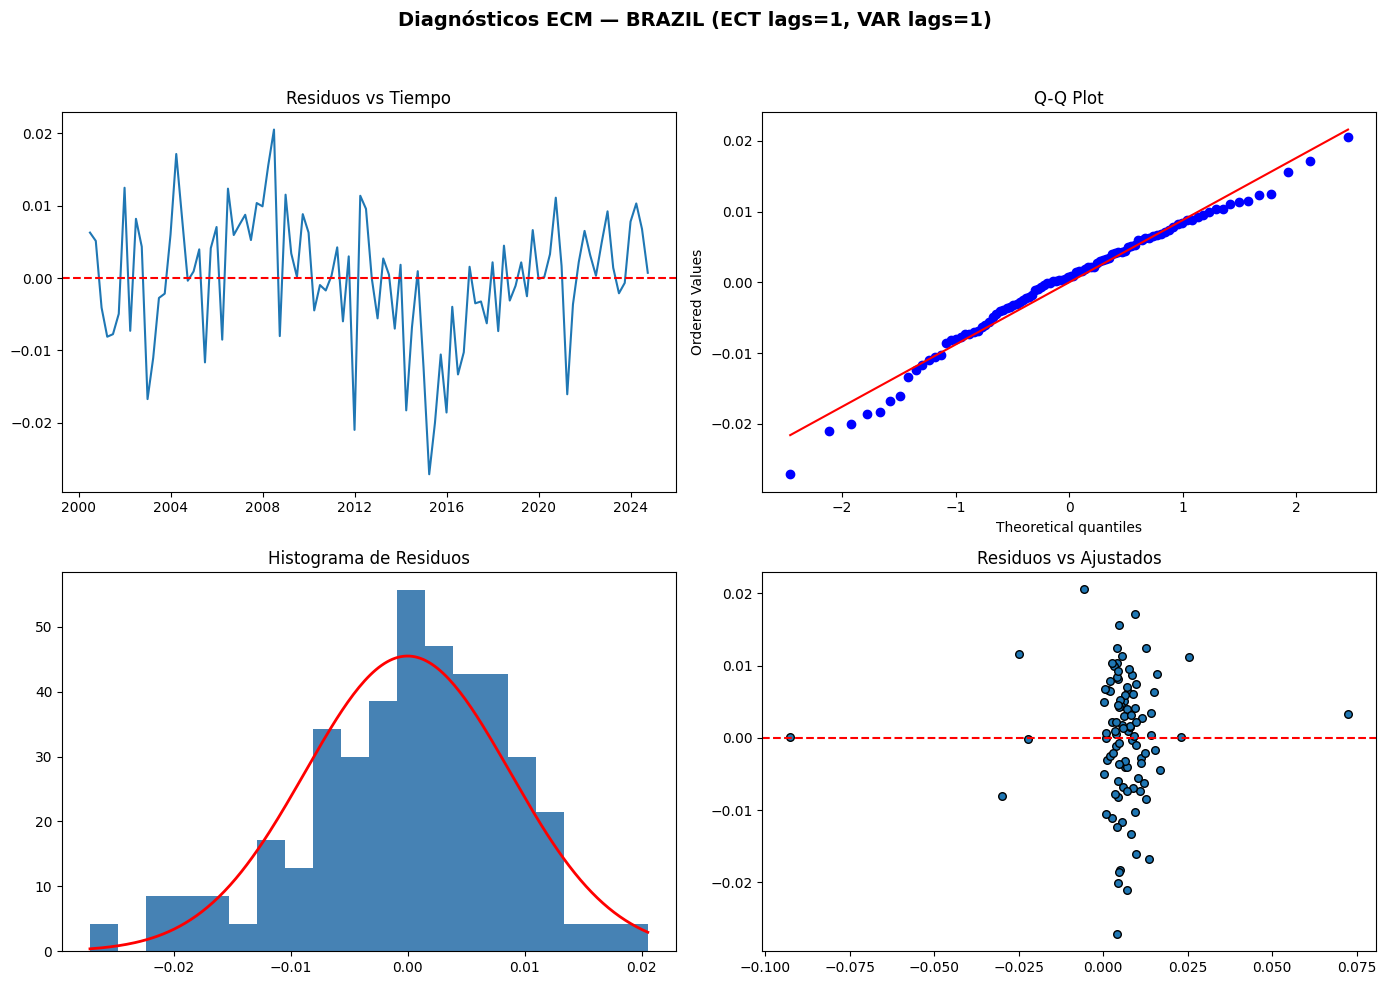


📈 PASO 3: Evolución del ECT (centrado)
ECT media: 0.0000 (centrado)
ECT std: 0.1004
ECT actual: 0.2984 (2.97 σ)


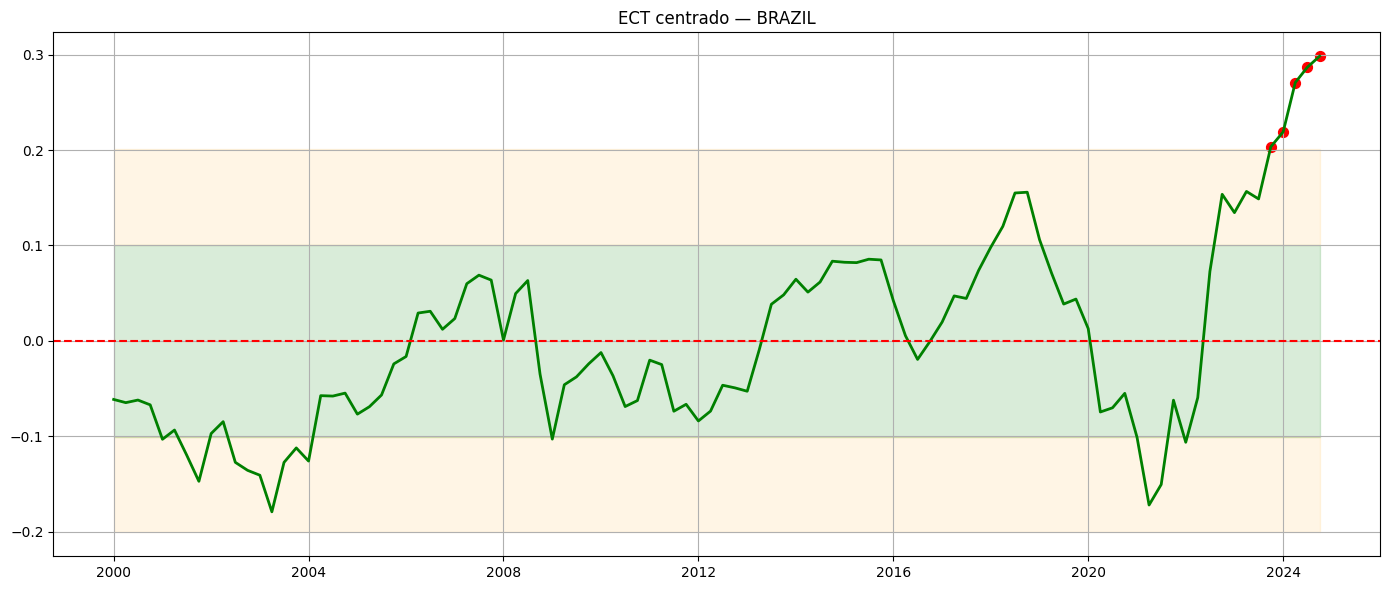


💡 PASO 4: Interpretación Económica del Modelo

1️⃣ Relación de Largo Plazo (OLS con constante)
   Ecuación de equilibrio:
   log_gdp_brazil = -27.2384 + 8.6668·log_tot_brazil + -0.0676·us_10y

2️⃣ Mecanismo de Corrección de Error
   • α = -0.0021 → Estable
   • Semivida ≈ 335.2 trimestres

3️⃣ Capacidad Explicativa
   • R² ajustado: 68.67%

4️⃣ Variables significativas (p<0.10):
   • log_ip_g7_L0: 0.4451 (p=0.000)
   • log_ip_g7_L1: -0.4405 (p=0.000)
   • covid_crash: -0.0129 (p=0.003)

💾 Diagnósticos guardados en 'diagnostics_summary'


In [39]:
# ==============================================================================
# FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import jarque_bera, probplot
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey

print("="*80)
print(f"🔍 FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO — {COUNTRY.upper()}")
print("="*80)

# ==============================================================================
# EXTRACCIÓN DEL MODELO FINAL Y LA RELACIÓN DE LARGO PLAZO
# ==============================================================================

modelo_final = final_model_results['model']
ect = final_model_results['ect']
spec = final_model_results['specification']

coint_cols  = final_model_results['coint_cols']
ols_params  = final_model_results['ols_params']     # <-- parámetros OLS del largo plazo
beta_vec    = final_model_results['beta']           # <-- solo informativo (Johansen-based)

# ==============================================================================
# 4.1: TESTS DE DIAGNÓSTICO
# ==============================================================================

print("\n📊 PASO 1: Tests de Diagnóstico de Residuos")
print("-"*60)

residuos = modelo_final.resid
exog = modelo_final.model.exog

# Jarque-Bera
jb_stat, jb_pvalue = jarque_bera(residuos)
print(f"✓ Jarque-Bera: stat={jb_stat:.3f}, p={jb_pvalue:.4f}")

# Autocorrelación
bg_stat, bg_pvalue, _, _ = acorr_breusch_godfrey(modelo_final, nlags=4)
print(f"✓ Breusch-Godfrey: stat={bg_stat:.3f}, p={bg_pvalue:.4f}")

# White
try:
    white_stat, white_pvalue, _, _ = het_white(residuos, exog)
    print(f"✓ White: stat={white_stat:.3f}, p={white_pvalue:.4f}")
except:
    print("⚠️ Test de White no disponible")

print("\n" + "="*60)
print("📋 Resumen de Diagnósticos")
print("="*60)
print(f"   • Normalidad: {'OK' if jb_pvalue>0.05 else 'No'}")
print(f"   • Autocorrelación: {'OK' if bg_pvalue>0.05 else 'No'}")
print(f"   • Heterocedasticidad: HAC robusto aplicado")

# ==============================================================================
# 4.2: GRÁFICOS DE DIAGNÓSTICO
# ==============================================================================

print("\n" + "="*60)
print("📈 PASO 2: Gráficos de Diagnóstico")
print("="*60)

fig, axes = plt.subplots(2,2, figsize=(14,10))
fig.suptitle(
    f'Diagnósticos ECM — {COUNTRY.upper()} (ECT lags={spec["ect_lags"]}, VAR lags={spec["var_lags"]})',
    fontsize=14, fontweight='bold'
)

# Residuos vs tiempo
ax1 = axes[0,0]
ax1.plot(residuos.index, residuos)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title("Residuos vs Tiempo")

# Q-Q plot
probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Q-Q Plot")

# Histograma
ax3 = axes[1,0]
ax3.hist(residuos, bins=20, density=True, color='steelblue')
mu, sd = residuos.mean(), residuos.std()
x = np.linspace(residuos.min(), residuos.max(), 200)
ax3.plot(x, 1/(sd*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu)/sd)**2), 'r-', lw=2)
ax3.set_title("Histograma de Residuos")

# Residuos vs Ajustados
ax4 = axes[1,1]
ax4.scatter(modelo_final.fittedvalues, residuos, s=30, edgecolor='black')
ax4.axhline(0, color='red', linestyle='--')
ax4.set_title("Residuos vs Ajustados")

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig(f"{figures_dir}/model_diagnostics.pdf", dpi=300)
plt.show()


# ==============================================================================
# 4.3: EVOLUCIÓN DEL ECT (centrado)
# ==============================================================================

print("\n" + "="*60)
print("📈 PASO 3: Evolución del ECT (centrado)")
print("="*60)

ect_centered = ect - ect.mean()
ect_std = ect_centered.std()
ect_cur = ect_centered.iloc[-1]

print(f"ECT media: 0.0000 (centrado)")
print(f"ECT std: {ect_std:.4f}")
print(f"ECT actual: {ect_cur:.4f} ({abs(ect_cur)/ect_std:.2f} σ)")

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(ect_centered.index, ect_centered, linewidth=2, color='green')
ax.axhline(0, color='red', linestyle='--')

# bandas
ax.fill_between(ect_centered.index, -ect_std, ect_std, alpha=0.15, color='green')
ax.fill_between(ect_centered.index, -2*ect_std, -ect_std, alpha=0.10, color='orange')
ax.fill_between(ect_centered.index, ect_std, 2*ect_std, alpha=0.10, color='orange')

# extremos
ax.scatter(ect_centered.index[ect_centered>2*ect_std],
           ect_centered[ect_centered>2*ect_std], color='red', s=50)
ax.scatter(ect_centered.index[ect_centered<-2*ect_std],
           ect_centered[ect_centered<-2*ect_std], color='blue', s=50)

ax.set_title(f"ECT centrado — {COUNTRY.upper()}")
ax.grid(True)

plt.tight_layout()
plt.savefig(f"{figures_dir}/ect_evolution_centered.pdf", dpi=300)
plt.show()


# ==============================================================================
# 4.4: INTERPRETACIÓN ECONÓMICA
# ==============================================================================

print("\n" + "="*80)
print("💡 PASO 4: Interpretación Económica del Modelo")
print("="*80)

ect_coef = modelo_final.params.get("ECT_L1", np.nan)
r2_adj   = modelo_final.rsquared_adj

print("\n1️⃣ Relación de Largo Plazo (OLS con constante)")
print("   Ecuación de equilibrio:")
eq = f"   {coint_cols[0]} = {ols_params['const']:.4f}"
for v in coint_cols[1:]:
    eq += f" + {ols_params[v]:.4f}·{v}"
print(eq)

print("\n2️⃣ Mecanismo de Corrección de Error")
print(f"   • α = {ect_coef:.4f} → {'Estable' if ect_coef<0 else 'No estable'}")
if ect_coef < 0:
    try:
        hl = -np.log(2)/np.log(1+ect_coef)
        print(f"   • Semivida ≈ {hl:.1f} trimestres")
    except:
        pass

print("\n3️⃣ Capacidad Explicativa")
print(f"   • R² ajustado: {r2_adj:.2%}")

print("\n4️⃣ Variables significativas (p<0.10):")
sig = modelo_final.pvalues[modelo_final.pvalues<0.10].index
sig = [v for v in sig if v!="const"]
for v in sig:
    print(f"   • {v}: {modelo_final.params[v]:.4f} (p={modelo_final.pvalues[v]:.3f})")

diagnostics_summary = {
    'ect_coefficient': ect_coef,
    'r_squared_adj': r2_adj,
    'jarque_bera_pvalue': jb_pvalue,
    'breusch_godfrey_pvalue': bg_pvalue,
    'ect_current': ect_cur,
    'ect_std': ect_std,
    'significant_variables': sig
}

print("\n💾 Diagnósticos guardados en 'diagnostics_summary'")
print("="*80)


## FASE 5 · Funciones Impulso–Respuesta (IRFs)

**Objetivo.** Cuantificar cómo shocks externos afectan al PIB trimestral y obtener los **cargadores** $g(H)$ para el índice (horizonte $H=4$).

**Qué hace esta celda.**
1) Extrae parámetros del **ECM final** ($\alpha$, betas contemporáneas) y de **cointegración** ($\gamma$).  
2) Calcula IRFs por tipo de shock:
   - **I(1)** (ToT, US10Y): impacto contemporáneo + convergencia vía $\mathrm{ECT}$ con velocidad $\alpha<0$; efecto de **largo plazo** dado por $\gamma$.
   - **I(0)** (IP\_G7, spread): shocks **transitorios** con persistencias $\rho$ ilustrativas.
   - **Evento extremo** (COVID): dummy con decaimiento por $\alpha$.

3) Visualiza IRFs (panel) y construye **tabla resumen** (impacto $t{=}0$, acumulado 1 año, largo plazo si aplica).  
4) Prepara insumos para la Fase 6: `irfs_dict`, columnas de shocks en `df_aligned`, vector $g(H)$ y ventana `win`.

**Cómo leer (resumen).**
- **ToT (+1\%)**: mayor contribución; efecto LR $\approx +8.67\%$, acumulado 1Y $\sim +1.73\%$.  
- **US10Y (+100 pb)**: efecto LR negativo $\approx -6.77\%$, acumulado 1Y $\sim -1.11\%$.  
- **IP\_G7** y **spread**: efectos **transitorios** y acotados.

**Nota.** Estas IRFs fundamentan pesos y signos del índice, pero no saturamos el informe con detalles: en el ejecutivo basta una figura compacta.



FASE 5: FUNCIONES IMPULSO-RESPUESTA — BRAZIL

PASO 1: Extracción de Parámetros del Modelo ECM
------------------------------------------------------------
Parámetros del ECM extraídos:
  alpha (ECT_L1): -0.002066
  β_D(log_tot_brazil)_L0: -0.088801
  β_D(us_10y)_L0: 0.002064
  β_D(log_ip_g7)_L0: 0.000000
  β_risk_spread_L0: -0.001094
  β_covid_crash: -0.012871
  β_covid_recovery: 0.001305

Coeficientes de largo plazo (a partir de la ecuación de cointegración OLS):
  gamma_log_tot_brazil:   8.666775
  gamma_us_10y: -0.067649
  gamma_log_ip_g7:    0.000000

PASO 2: Estimación de persistencia en I(0)
------------------------------------------------------------
  ρ(risk_spread) = 0.864
  ρ(log_ip_g7) = 0.775

PASO 3: Cálculo de Funciones Impulso-Respuesta

Calculando IRFs para cada tipo de shock...

  Shock ToT (+1%): impacto inicial = -0.0888%, acum 1 año = -0.0347%, largo plazo = 8.6668%

  Shock US10Y (+100 bps): impacto inicial = 0.0021, acum 1 año = 0.0016, largo plazo = -0.0676

  Sh

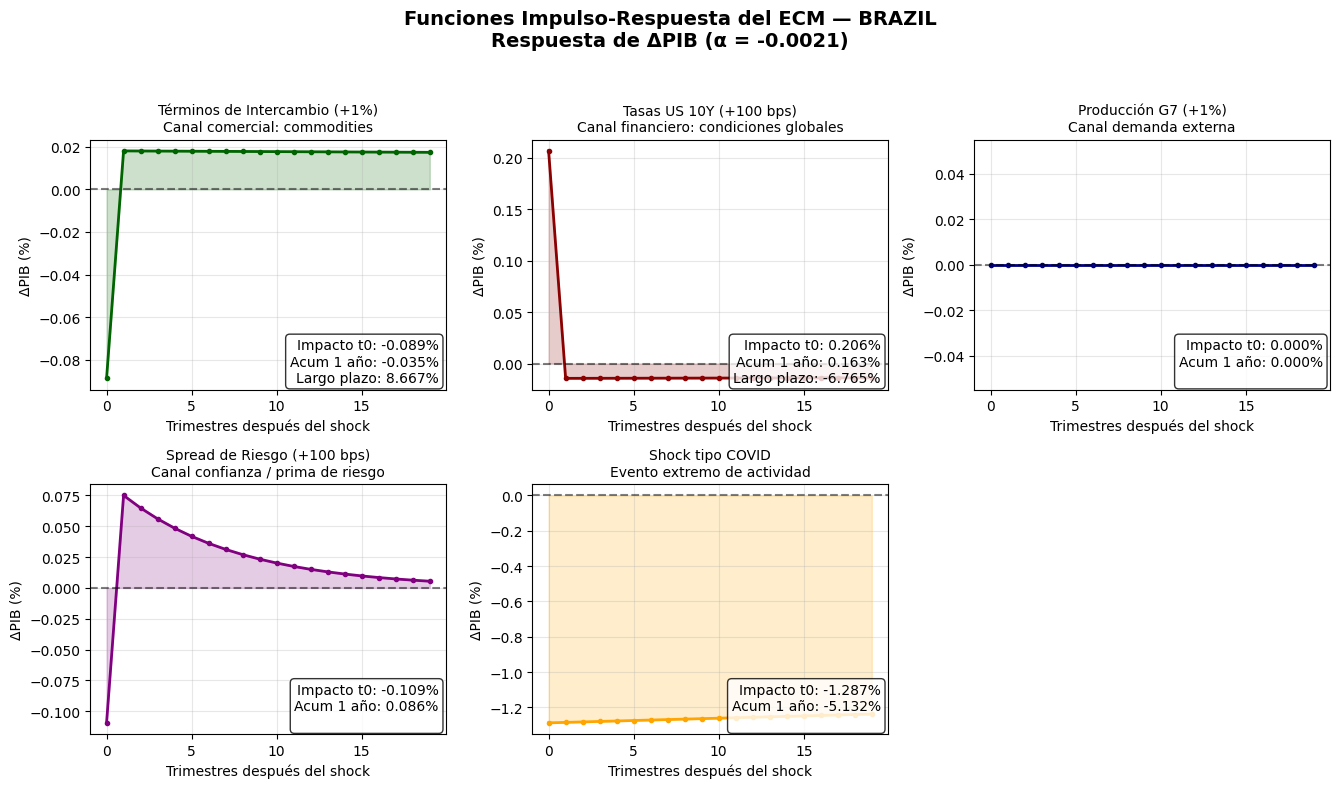


PASO 5: Tabla Resumen de IRFs

                        Shock  Magnitud t=0 (%) t=1 (%) t=4 (%) Acum 1 año (%) Largo Plazo (%)
Términos de Intercambio (+1%)        1% -0.0888  0.0181  0.0180        -0.0347          8.6668
      Tasas US 10Y (+100 bps)   100 bps  0.2064 -0.0144 -0.0143         0.1633         -6.7649
          Producción G7 (+1%)        1%  0.0000  0.0000  0.0000         0.0000          0.0000
  Spread de Riesgo (+100 bps)   100 bps -0.1094  0.0749  0.0484         0.0863          0.0000
             Shock tipo COVID dummy = 1 -1.2871 -1.2844 -1.2765        -5.1324          0.0000

PUENTE FASE 5 → FASE 6: Construcción de g(H)
   Horizonte H = 4 trimestres
   Shock columns: ['d_log_tot_brazil', 'd_us10y', 'd_spread', 'd_log_ip_g7']
   g(H) = [-0.00034656  0.00163338  0.00086288  0.        ]

FASE 5 COMPLETADA — IRFs e inputs para FASE 6 listos.


In [40]:
# ==============================================================================
# FASE 5: FUNCIONES IMPULSO-RESPUESTA (IRFs)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg


print("="*80)
print(f"FASE 5: FUNCIONES IMPULSO-RESPUESTA — {COUNTRY.upper()}")
print("="*80)

# =============================================================
# Recuperación robusta del modelo de cointegración
# =============================================================
cfg = COUNTRY_CONFIG[COUNTRY]
modelo_final = final_model_results['model']
params = modelo_final.params


# Caso actual: cointegración guardada como claves sueltas
if 'coint_cols' in final_model_results and 'beta' in final_model_results:
    coint_cols = final_model_results['coint_cols']     # lista de variables
    beta_vec   = final_model_results['beta']           # vector beta normalizado
    coint_params = final_model_results['ols_params']   # params OLS (const + betas)
else:
    raise ValueError("Faltan coint_cols y beta en final_model_results.")


# ==============================================================================#
# 5.1: EXTRACCIÓN Y VERIFICACIÓN DE PARÁMETROS
# ==============================================================================

print("\nPASO 1: Extracción de Parámetros del Modelo ECM")
print("-"*60)

alpha = params.get('ECT_L1', 0.0)   # velocidad de ajuste

# Nombres de variables “económicas” clave (dependen del país vía cfg)
y_var      = cfg['log_gdp_col']   # PIB log
tot_var    = cfg['log_tot_col']   # ToT país
ip_var     = cfg['ip_log_col']    # IP G7 ponderado
us10y_var  = 'us_10y'
spread_var = 'risk_spread'

# Coeficientes contemporáneos en diferencias (I(1))
beta_dtot   = params.get(f'D_{tot_var}_L0',   0.0)
beta_dus10y = params.get('D_us_10y_L0',       0.0)
beta_dip    = params.get(f'D_{ip_var}_L0',    0.0)

# Coeficientes en niveles (I(0)) para el spread (pueden aparecer varios lags)
beta_spread_levels = {k: v for k, v in params.items() if k.startswith(f'{spread_var}_L')}
beta_spread_L0 = beta_spread_levels.get(f'{spread_var}_L0', 0.0)

beta_covid_crash    = params.get('covid_crash',    0.0)
beta_covid_recovery = params.get('covid_recovery', 0.0)

print(f"Parámetros del ECM extraídos:")
print(f"  alpha (ECT_L1): {alpha:.6f}")
print(f"  β_D({tot_var})_L0: {beta_dtot:.6f}")
print(f"  β_D({us10y_var})_L0: {beta_dus10y:.6f}")
print(f"  β_D({ip_var})_L0: {beta_dip:.6f}")
print(f"  β_{spread_var}_L0: {beta_spread_L0:.6f}")
print(f"  β_covid_crash: {beta_covid_crash:.6f}")
print(f"  β_covid_recovery: {beta_covid_recovery:.6f}")


# ==============================================================================
# 5.1.b: COEFICIENTES DE LARGO PLAZO A PARTIR DE LA ECUACIÓN OLS
# ==============================================================================

print("\nCoeficientes de largo plazo (a partir de la ecuación de cointegración OLS):")

# coint_params contiene: const y coeficientes de las variables en coint_cols[1:]
# y_t = const + Σ γ_j * x_{jt}
def get_gamma(var_name, coint_params):
    try:
        return float(coint_params.get(var_name, 0.0))
    except Exception:
        return 0.0

gamma_tot   = get_gamma(tot_var,   coint_params)
gamma_us10y = get_gamma(us10y_var, coint_params)
gamma_ip    = get_gamma(ip_var,    coint_params)

print(f"  gamma_{tot_var}:   {gamma_tot:.6f}")
print(f"  gamma_{us10y_var}: {gamma_us10y:.6f}")
print(f"  gamma_{ip_var}:    {gamma_ip:.6f}")


# ==============================================================================
# 5.2: PERSISTENCIA EMPÍRICA EN VARIABLES I(0)
# ==============================================================================

print("\nPASO 2: Estimación de persistencia en I(0)")
print("-"*60)

# Spread: AR(1) como aproximación de persistencia
try:
    rho_spread = AutoReg(df_aligned[spread_var].dropna(), lags=1).fit().params[1]
except Exception:
    rho_spread = 0.8
print(f"  ρ({spread_var}) = {rho_spread:.3f}")

# Persistencia para IP_G7 (aunque sea I(1), se usa solo si no participa en cointegración)
try:
    rho_ip = AutoReg(df_aligned[ip_var].dropna(), lags=1).fit().params[1]
except Exception:
    rho_ip = 0.9
print(f"  ρ({ip_var}) = {rho_ip:.3f}")


# ==============================================================================
# 5.3: CÁLCULO DE IRFs
# ==============================================================================

print("\n" + "="*60)
print("PASO 3: Cálculo de Funciones Impulso-Respuesta")
print("="*60)

def irf_permanent_I1(short_beta, gamma, alpha, shock_size, periods=20):
    """
    Shock permanente sobre variable I(1) que participa (o no) en cointegración.
    Aproximación:
      - Impacto contemporáneo vía coeficiente de corto plazo (short_beta) en Δy_t.
      - Ajuste de largo plazo vía ECT con velocidad α y elasticidad γ.
    """
    resp = np.zeros(periods)

    # Impacto inicial en Δy_t
    resp[0] = short_beta * shock_size

    # Contribución vía ECT a partir de t=1 (si hay cointegración y ajuste estable)
    if alpha < 0 and gamma != 0:
        for t in range(1, periods):
            resp[t] = alpha * (short_beta - gamma) * shock_size * ((1 + alpha) ** (t-1))
        long_run = gamma * shock_size
    else:
        long_run = 0.0

    info = {
        'impact': resp[0],
        'period_1': resp[1] if periods > 1 else np.nan,
        'cumulative_4q': float(resp[:4].sum()),
        'long_run': long_run,
        'half_life': -np.log(2) / np.log(1 + alpha) if alpha < 0 else np.inf
    }
    return resp, info


def irf_I0_with_AR(short_betas_dict, rho, shock_size, periods=20):
    """
    Shock sobre variable I(0) z_t con dinámica AR(1): z_t = ρ z_{t-1} + ε_t.
    Ecuación de Δy_t incluye z_t, z_{t-1}, ...
    IRF en Δy_t: Σ b_k * ρ^{t-k} * shock_size.
    short_betas_dict: { 'L0': b0, 'L1': b1, ... }
    """
    resp = np.zeros(periods)
    if len(short_betas_dict) == 0:
        info = {
            'impact': 0.0,
            'period_1': 0.0,
            'cumulative_4q': 0.0,
            'long_run': 0.0,
            'persistence': rho
        }
        return resp, info

    for t in range(periods):
        val = 0.0
        for k_label, b in short_betas_dict.items():
            lag = int(k_label.replace('L', ''))
            if t - lag >= 0:
                val += b * (rho ** (t - lag)) * shock_size
        resp[t] = val

    info = {
        'impact': resp[0],
        'period_1': resp[1] if periods > 1 else np.nan,
        'cumulative_4q': float(resp[:4].sum()),
        'long_run': 0.0,
        'persistence': rho
    }
    return resp, info


def irf_dummy(alpha, beta_dummy, periods=20):
    """
    Shock tipo dummy (covid_crash = 1 en t=0), propagado vía α (inercia del sistema).
    """
    resp = np.zeros(periods)
    resp[0] = beta_dummy
    for t in range(1, periods):
        resp[t] = resp[t-1] * (1 + alpha)
    info = {
        'impact': resp[0],
        'cumulative_4q': float(resp[:4].sum()),
        'long_run': 0.0,
        'half_life': -np.log(2) / np.log(1 + alpha) if alpha < 0 else np.inf
    }
    return resp, info


# ------------------------------------------------------------------------------#
# 5.4: CÁLCULO EFECTIVO DE IRFs PARA CADA SHOCK
# ------------------------------------------------------------------------------

print("\nCalculando IRFs para cada tipo de shock...")

irf_results = {}

# 1) Shock en Términos de Intercambio (I(1))
resp_tot, info_tot = irf_permanent_I1(
    short_beta = beta_dtot,
    gamma      = gamma_tot,
    alpha      = alpha,
    shock_size = 0.01,      # +1 % en ToT
    periods    = 20
)
irf_results[tot_var] = {
    'response': resp_tot,
    'info': info_tot,
    'config': {
        'name': 'Términos de Intercambio (+1%)',
        'shock_size': 0.01,
        'color': 'darkgreen',
        'description': 'Canal comercial: commodities'
    }
}
print(f"\n  Shock ToT (+1%): impacto inicial = {info_tot['impact']*100:.4f}%, "
      f"acum 1 año = {info_tot['cumulative_4q']*100:.4f}%, "
      f"largo plazo = {info_tot['long_run']*100:.4f}%")


# 2) Shock en US 10Y (I(1))
resp_us10y, info_us10y = irf_permanent_I1(
    short_beta = beta_dus10y,
    gamma      = gamma_us10y,
    alpha      = alpha,
    shock_size = 1.0,       # +100 bps
    periods    = 20
)
irf_results[us10y_var] = {
    'response': resp_us10y,
    'info': info_us10y,
    'config': {
        'name': 'Tasas US 10Y (+100 bps)',
        'shock_size': 1.0,
        'color': 'darkred',
        'description': 'Canal financiero: condiciones globales'
    }
}
print(f"\n  Shock US10Y (+100 bps): impacto inicial = {info_us10y['impact']:.4f}, "
      f"acum 1 año = {info_us10y['cumulative_4q']:.4f}, "
      f"largo plazo = {info_us10y['long_run']:.4f}")


# 3) Shock en IP_G7
# Si IP está en cointegración → I(1) con efecto de largo plazo.
# Si NO está en la relación de largo plazo → efecto transitorio vía AR(1) en niveles.
if gamma_ip != 0:
    resp_ip, info_ip = irf_permanent_I1(
        short_beta = beta_dip,
        gamma      = gamma_ip,
        alpha      = alpha,
        shock_size = 0.01,     # +1 % en IP_G7
        periods    = 20
    )
else:
    resp_ip, info_ip = irf_I0_with_AR(
        short_betas_dict = {'L0': beta_dip},
        rho              = rho_ip,
        shock_size       = 0.01,
        periods          = 20
    )

irf_results[ip_var] = {
    'response': resp_ip,
    'info': info_ip,
    'config': {
        'name': 'Producción G7 (+1%)',
        'shock_size': 0.01,
        'color': 'navy',
        'description': 'Canal demanda externa'
    }
}
print(f"\n  Shock IP_G7 (+1%): impacto inicial = {info_ip['impact']*100:.4f}%, "
      f"acum 1 año = {info_ip['cumulative_4q']*100:.4f}%, "
      f"largo plazo = {info_ip.get('long_run',0)*100:.4f}%")


# 4) Shock en Spread de Riesgo (I(0))
short_betas_spread = {k.replace(f'{spread_var}_', ''): v for k, v in beta_spread_levels.items()}
resp_spread, info_spread = irf_I0_with_AR(
    short_betas_dict = short_betas_spread,
    rho              = rho_spread,
    shock_size       = 1.0,     # +100 bps
    periods          = 20
)
irf_results[spread_var] = {
    'response': resp_spread,
    'info': info_spread,
    'config': {
        'name': 'Spread de Riesgo (+100 bps)',
        'shock_size': 1.0,
        'color': 'purple',
        'description': 'Canal confianza / prima de riesgo'
    }
}
print(f"\n  Shock Spread (+100 bps): impacto inicial = {info_spread['impact']:.4f}, "
      f"acum 1 año = {info_spread['cumulative_4q']:.4f}")


# 5) Shock tipo COVID (solo si está en el modelo final)
if 'covid_crash' in params.index and beta_covid_crash != 0:
    resp_covid, info_covid = irf_dummy(alpha, beta_covid_crash, periods=20)
    irf_results['covid_crash'] = {
        'response': resp_covid,
        'info': info_covid,
        'config': {
            'name': 'Shock tipo COVID',
            'shock_size': 1.0,
            'color': 'orange',
            'description': 'Evento extremo de actividad'
        }
    }
    print(f"\n  Shock COVID: impacto inicial = {info_covid['impact']:.4f}, "
          f"acum 1 año = {info_covid['cumulative_4q']:.4f}")


# ==============================================================================
# 5.5: VISUALIZACIÓN DE IRFs
# ==============================================================================

print("\n" + "="*60)
print("PASO 4: Visualización de IRFs")
print("="*60)

n_shocks = len(irf_results)
n_rows = 2
n_cols = int(np.ceil(n_shocks / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5*n_cols, 4*n_rows))
axes = np.array(axes).reshape(-1)
fig.suptitle(f'Funciones Impulso-Respuesta del ECM — {COUNTRY.upper()}\n'
             f'Respuesta de ΔPIB (α = {alpha:.4f})',
             fontsize=14, fontweight='bold')

for ax, (var, data) in zip(axes, irf_results.items()):
    cfg_shock = data['config']
    resp      = data['response'] * 100  # a %
    info      = data['info']
    h         = np.arange(len(resp))

    ax.plot(h, resp, color=cfg_shock['color'], linewidth=2, marker='o', ms=3)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.fill_between(h, 0, resp, color=cfg_shock['color'], alpha=0.2)

    ax.set_title(f"{cfg_shock['name']}\n{cfg_shock['description']}", fontsize=10)
    ax.set_xlabel('Trimestres después del shock')
    ax.set_ylabel('ΔPIB (%)')
    ax.grid(True, alpha=0.3)

    txt  = f"Impacto t0: {info['impact']*100:.3f}%\n"
    txt += f"Acum 1 año: {info['cumulative_4q']*100:.3f}%\n"
    if 'long_run' in info and info['long_run'] != 0:
        txt += f"Largo plazo: {info['long_run']*100:.3f}%"
    ax.text(0.98, 0.02, txt, transform=ax.transAxes,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round', fc='white', ec='black', alpha=0.8))

# Si sobran ejes vacíos, eliminarlos
for ax in axes[n_shocks:]:
    fig.delaxes(ax)

plt.tight_layout(rect=[0,0,1,0.95])
fname_irf = f"{figures_dir}/irf_ecm_{COUNTRY.lower()}.pdf"
plt.savefig(fname_irf, dpi=300, bbox_inches='tight')
print(f"\nFigura guardada: {fname_irf}")
plt.show()


# ==============================================================================
# 5.6: TABLA RESUMEN DE IRFs
# ==============================================================================

print("\n" + "="*80)
print("PASO 5: Tabla Resumen de IRFs")
print("="*80)

summary_rows = []
for var, data in irf_results.items():
    cfg_shock = data['config']
    info      = data['info']
    resp      = data['response']

    # Magnitud: % si shock_size<1 y no es bps, "100 bps" si nombre incluye 'bps',
    # y "dummy = 1" para shock COVID.
    if 'COVID' in cfg_shock['name']:
        magnitud_str = "dummy = 1"
    elif 'bps' in cfg_shock['name']:
        magnitud_str = f"{int(cfg_shock['shock_size']*100)} bps"  # 1.0 → 100 bps
    else:
        magnitud_str = f"{cfg_shock['shock_size']*100:.0f}%"

    row = {
        'Shock': cfg_shock['name'],
        'Magnitud': magnitud_str,
        't=0 (%)': f"{info['impact']*100:.4f}",
        't=1 (%)': f"{resp[1]*100:.4f}" if len(resp)>1 else "N/A",
        't=4 (%)': f"{resp[4]*100:.4f}" if len(resp)>4 else "N/A",
        'Acum 1 año (%)': f"{info['cumulative_4q']*100:.4f}",
        'Largo Plazo (%)': f"{info.get('long_run', 0)*100:.4f}"
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\n" + summary_df.to_string(index=False))


# ==============================================================================
# 5.7: PUENTE HACIA FASE 6 — g(H)
# ==============================================================================

print("\n" + "="*80)
print("PUENTE FASE 5 → FASE 6: Construcción de g(H)")
print("="*80)

# Horizonte H en trimestres
H = 4

def irf_loadings_for_horizon(irf_results, shock_keys, H):
    g_list = []
    for key in shock_keys:
        series = pd.Series(irf_results[key]['response'])
        g_list.append(float(series.iloc[:H].sum()))
    return np.array(g_list, dtype='float64')

# Shocks empíricos en df_aligned:
#   - Δ para I(1)
#   - nivel para I(0)
df_aligned = df_aligned.copy()
df_aligned[f'd_{tot_var}'] = df_aligned[tot_var].diff()
df_aligned['d_us10y']      = df_aligned[us10y_var].diff()
df_aligned['d_spread']     = df_aligned[spread_var].diff()   # CORRECTO
df_aligned[f'd_{ip_var}']  = df_aligned[ip_var].diff()


shock_cols = [f'd_{tot_var}', 'd_us10y', 'd_spread', f'd_{ip_var}']
df_aligned[shock_cols] = df_aligned[shock_cols].astype(float)

# Mapeo shock_cols → claves de irf_results
shock_key_map = {
    f'd_{tot_var}': tot_var,
    'd_us10y':      us10y_var,
    'd_spread':     spread_var,
    f'd_{ip_var}':  ip_var
}
shock_keys_for_g = [shock_key_map[c] for c in shock_cols]

g = irf_loadings_for_horizon(irf_results, shock_keys_for_g, H=H)

print(f"   Horizonte H = {H} trimestres")
print(f"   Shock columns: {shock_cols}")
print(f"   g(H) = {g}")

print("\nFASE 5 COMPLETADA — IRFs e inputs para FASE 6 listos.")
print("="*80)


In [41]:
# ==============================================================================
# FASE 5 — EXPORTACIÓN DE INPUTS DEL IVE
# ==============================================================================

import pickle

print("="*80)
print(f"📦 EXPORTACIÓN DE INPUTS PARA EL IVE — {COUNTRY.upper()}")
print("="*80)

# -----------------------------------------------------------
# 1) Asegurar que H y win existen (si no, usar defaults)
# -----------------------------------------------------------
if 'H' not in globals():
    H = 4
if 'win' not in globals():
    win = 40

H_ive = H
win_ive = win

# -----------------------------------------------------------
# 2) Extraer componentes del modelo final
# -----------------------------------------------------------
ect_series = final_model_results['ect'].copy()
df_shocks  = df_aligned[shock_cols].copy()
gH         = g.copy()
model_params = final_model_results['model'].params.copy()
irfs_full    = irf_results.copy()

# Empaquetar todo en un diccionario
ive_inputs = {
    'country': COUNTRY,
    'ect': ect_series,
    'df_shocks': df_shocks,
    'shock_cols': shock_cols,
    'gH': gH,
    'H': H_ive,
    'win': win_ive,
    'model_params': model_params,
    'irfs_dict': irfs_full
}

# Guardar archivo
output_file = f"ive_inputs_{COUNTRY.lower()}.pkl"
with open(output_file, "wb") as f:
    pickle.dump(ive_inputs, f)

print(f"✅ Archivo creado: {output_file}")
print(f"   • País: {COUNTRY.upper()}")
print(f"   • Observaciones shocks: {df_shocks.shape}")
print(f"   • Longitud ECT: {len(ect_series)}")
print(f"   • Horizonte H: {H_ive}")
print(f"   • Ventana win: {win_ive}")
print("="*80)


📦 EXPORTACIÓN DE INPUTS PARA EL IVE — BRAZIL
✅ Archivo creado: ive_inputs_brazil.pkl
   • País: BRAZIL
   • Observaciones shocks: (100, 4)
   • Longitud ECT: 100
   • Horizonte H: 4
   • Ventana win: 40


## FASE 6 · Construcción del Indicador de Vulnerabilidad (componentes → pesos → índice)

**Objetivo.** Construir el **Índice de Vulnerabilidad Externa (IVE)** combinando dos piezas:
1) **Desequilibrio**: $|\mathrm{ECT}|$ (desviación del equilibrio de largo plazo).  
2) **Volatilidad**: desviación estándar móvil de los **residuos** del ECM ($\sigma_t$).

Ambos se **estandarizan** (z-score) y se agregan con pesos $\mathbf{w}=(w_1,w_2)$ elegidos para **maximizar la capacidad de alerta**: buscamos la **correlación más negativa** posible con el crecimiento futuro ($\Delta \text{PIB}_{t+h}$, típicamente $h=1$ año).

**Qué hace esta celda.**
- `build_essential_components(...)`: crea los dos componentes $|\mathrm{ECT}|$ y $\sigma_t$ a partir del `ECT` y de los **residuos** del modelo; permite pasar series externas (de `final_model_results`) o columnas de `df_aligned`.  
- `optimize_vulnerability_weights(...)`: optimiza $\mathbf{w}$ con **SLSQP** bajo restricciones **no negatividad** y **suma a 1**, y con opción de **excluir** observaciones (p. ej., COVID) de la función objetivo.  
- `create_optimized_vulnerability_indicator(...)`: aplica $\mathbf{w}^\*$ a toda la muestra y devuelve el índice.  
- `classify_vulnerability(...)`: asigna **colores** por percentiles (p50/p75/p90 → Verde/Amarillo/Naranja/Rojo).  
- `save_vulnerability_outputs(...)`: guarda CSV con la serie/clase y otro CSV con los **pesos**.

**Parámetros importantes.**
- Ventana de volatilidad: `vol_window=8` (trimestres) y `min_periods=4`.  
- Estandarización: `standardize=True` (recomendado para comparabilidad temporal).  
- Optimización: `bounds=[(0,1),(0,1)]`, `sum_to_one=True`.  
- Exclusiones: `exclude_mask=True` para fechas **a excluir** en la optimización (p. ej., 2020–2021H1).

**Uso típico (siguiente celda):**
```python
components = build_essential_components(
    df_aligned,
    ect_series=final_model_results['ect'],
    resid_series=final_model_results['model'].resid,
    vol_window=8, min_periods=4, standardize=True
)

# Objetivo: crecimiento futuro (t+4) o el que definas
target = df_aligned['dlog_pib_future_4']  # ejemplo

# Excluir COVID de la optimización (pero no del índice)
exclude = (df_aligned.index >= '2020-01') & (df_aligned.index <= '2021-06')

opt = optimize_vulnerability_weights(components, target, exclude_mask=exclude)
ive = create_optimized_vulnerability_indicator(components, opt['w_opt'])
ive_clasif = classify_vulnerability(ive)

save_vulnerability_outputs(ive_clasif, opt['w_opt'], figures_dir='figures', country_tag='brazil')



In [42]:
# ==============================================================================
# FASE 6: CONSTRUCCIÓN DEL INDICADOR DE VULNERABILIDAD (ECM–AGNÓSTICO)
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import os

figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

# ============================================================
# UTILIDAD: Z-score robusto
# ============================================================
def _zscore(x: pd.Series) -> pd.Series:
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=1)
    if sd == 0 or np.isnan(sd):
        return x * 0
    return (x - mu) / sd


# ==============================================================================
# 6.1 CONSTRUCCIÓN DE COMPONENTES (Totalmente generalizado)
# ==============================================================================

def build_components_for_ive(
    df_aligned: pd.DataFrame,
    final_model_results: dict,
    vol_window: int = 8,
    min_periods: int = 4,
    standardize: bool = True
) -> pd.DataFrame:
    """
    Construye los dos componentes esenciales del IVE:
    - Desequilibrio |ECT|
    - Volatilidad: std rolling de residuos ECM

    Ambos se estandarizan (z-score) si standardize=True.
    Todo se hace **automáticamente** a partir de final_model_results.
    """

    # 1) ECT óptimo procedente de Fase 3
    ect = final_model_results['ect'].copy()
    ect = ect.reindex(df_aligned.index)
    comp_deseq = ect.abs().rename("Desequilibrio")

    # 2) Residuos ECM óptimos
    resid = final_model_results['model'].resid.copy()
    resid = resid.reindex(df_aligned.index)

    comp_vol = resid.rolling(vol_window, min_periods=min_periods).std().rename("Volatilidad")

    # 3) Estandarización
    if standardize:
        comp_deseq = _zscore(comp_deseq)
        comp_vol   = _zscore(comp_vol)

    return pd.concat([comp_deseq, comp_vol], axis=1)


# ==============================================================================
# 6.2 OPTIMIZACIÓN DE PESOS — COMPLETAMENTE DINÁMICO
# ==============================================================================

def optimize_vulnerability_weights(
    components: pd.DataFrame,
    target: pd.Series,
    exclude_mask: pd.Series = None,
    bounds=((0.0, 1.0),(0.0, 1.0)),
    sum_to_one=True
) -> dict:

    comps = components.copy()
    targ  = target.copy()

    # Eliminamos COVID si corresponde
    if exclude_mask is not None:
        mask = (~exclude_mask.astype(bool))
        comps = comps[mask]
        targ  = targ[mask]

    # dimensiones
    k = comps.shape[1]
    w0 = np.full(k, 1.0/k)

    constraints = []
    if sum_to_one:
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    def objective(w):
        ind = pd.Series(comps.values @ w, index=comps.index)
        Z = pd.concat([ind, targ], axis=1).dropna()
        if len(Z) < 10:
            return 1e3
        corr = Z.iloc[:,0].corr(Z.iloc[:,1])
        if np.isnan(corr):
            return 1e3
        # Queremos correlación más negativa
        return corr

    res = minimize(
        objective, w0, method='SLSQP',
        bounds=bounds, constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 200}
    )

    if not res.success or np.any(np.isnan(res.x)):
        w_opt = w0
        success = False
    else:
        w_opt = res.x
        success = True

    # Correlación in–sample
    ind_opt = pd.Series(components.values @ w_opt, index=components.index)
    Z = pd.concat([ind_opt, target], axis=1).dropna()
    corr_in = Z.iloc[:,0].corr(Z.iloc[:,1]) if len(Z) > 10 else np.nan

    return {
        "w_opt": w_opt,
        "success": success,
        "corr_in_sample": corr_in,
        "n_obs_optim": len(Z)
    }


# ==============================================================================
# 6.3 CREAR INDICADOR FINAL
# ==============================================================================

def create_vulnerability_indicator(components: pd.DataFrame, w_opt: np.ndarray) -> pd.Series:
    ind = pd.Series(components.values @ w_opt, index=components.index, name="IVE")
    return ind


# ==============================================================================
# 6.4 CLASIFICACIÓN DEL IVE EN COLORES
# ==============================================================================

def classify_vulnerability(indicator: pd.Series,
                           p_cuts=(0.50, 0.75, 0.90),
                           labels=("Verde","Amarillo","Naranja","Rojo")):

    q50, q75, q90 = indicator.quantile(p_cuts).values

    def classify(x):
        if x < q50:     return labels[0]
        elif x < q75:   return labels[1]
        elif x < q90:   return labels[2]
        else:           return labels[3]

    return pd.DataFrame({
        "IVE": indicator,
        "Class": indicator.apply(classify)
    })


# ==============================================================================
# 6.5 GUARDAR RESULTADOS
# ==============================================================================

def save_vulnerability_outputs(df_out: pd.DataFrame,
                               w_opt: np.ndarray,
                               country_tag: str,
                               figures_dir="figures"):
    os.makedirs(figures_dir, exist_ok=True)

    # Guardar serie
    path_series = os.path.join(figures_dir,
                               f"IVE_{country_tag}.csv")
    df_out.to_csv(path_series)

    # Guardar pesos
    path_w = os.path.join(figures_dir,
                          f"IVE_weights_{country_tag}.csv")
    pd.DataFrame([w_opt],
                 columns=["w_desequilibrio","w_volatilidad"]).to_csv(path_w,
                                                                     index=False)

    print(f"[F6] Guardado:")
    print(f"   • Serie IVE:     {path_series}")
    print(f"   • Pesos óptimos: {path_w}")


### Fase 6 · Indicador ESD con amplificador de riesgo y λ endógeno

Esta celda estima y construye el **indicador de vulnerabilidad ESD** (*Equilibrium–Shock Disequilibrium*) para Brasil, integrando el componente estructural del desequilibrio (μₜ) con la volatilidad externa (σₜ).  
El procedimiento consta de los siguientes pasos:

1. **Cálculo de μₜ y σₜ:**
   - μₜ se obtiene del término de corrección de error (ECT) del modelo ECM, representando el desequilibrio interno.
   - σₜ mide el riesgo externo como la volatilidad proyectada de los shocks (√(g'Σg)) en una ventana móvil de 40 trimestres.

2. **Estimación del parámetro λ (amplificador de riesgo):**
   - λ pondera el efecto del riesgo: $( V_t = -(\mu_t / \sigma_t)(\sigma_t / \sigma_{ref})^{λ} )$.
   - Se busca el λ que **maximiza la correlación negativa** con el crecimiento del PIB a t+1 mediante un proceso continuo (`minimize_scalar`).
   - Además, se aplica un **criterio de saturación**: el proceso se detiene cuando las mejoras en correlación son inferiores a 0.002 durante tres pasos consecutivos, evitando sobreajustar el peso del riesgo.

3. **Construcción del índice ESD final:**
   - El índice combina desequilibrio y riesgo amplificado con el λ óptimo (λ*).
   - Se clasifica en cuartiles para identificar fases de vulnerabilidad (“verde” a “rojo”).
   - Se exporta el resultado a `vulnerability_brazil_ESD.csv`.

4. **Visualización:**
   - Se genera una figura principal que muestra la evolución del índice y los episodios de alta vulnerabilidad (percentil 75).
   - El índice puede interpretarse como un termómetro de fragilidad macro-financiera: valores positivos implican desequilibrio amplificado por condiciones de riesgo global.

Este enfoque une la dimensión estructural (μₜ) y la coyuntural (σₜ) en un indicador único y ajusta de forma endógena el grado de sensibilidad al riesgo global.



=== SHOCKS ESD ===
Shock cols: ['d_log_tot_brazil', 'd_us10y', 'd_spread', 'd_log_ip_g7']
g(H): [-0.00034656  0.00163338  0.00086288  0.        ]
λ* continuo (mínimo numérico): 4.804  |  corr = -0.460
→ Curva de correlación saturada en λ ≈ 3.000 (mejoras < 0.002 en 3 pasos consecutivos)
Guardado CSV: vulnerability_brazil_ESD.csv  |  λ*=3.000  |  σ_ref=0.0011


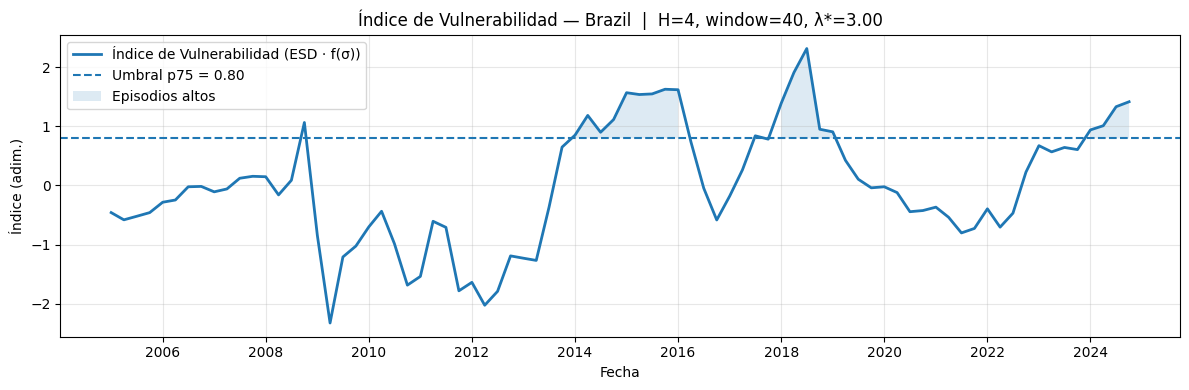

Gráfico guardado: vulnerability_esd_overview_brazil.pdf
FASE 6 ESD COMPLETADA


In [43]:
# ==============================================================================
# FASE 6 · INDICADOR ESD (generalizado por país)
# Requiere: df_aligned, final_model_results, irf_results, COUNTRY, COUNTRY_CONFIG
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
from scipy.optimize import minimize_scalar
import os
import re

# ---------- 0) Comprobaciones de entorno
assert 'df_aligned' in globals(), "Falta df_aligned"
assert 'final_model_results' in globals(), "Falta final_model_results"
assert 'irf_results' in globals(), "Falta irf_results (ejecuta FASE 5 antes)"
assert 'COUNTRY' in globals(), "Falta COUNTRY"
assert 'COUNTRY_CONFIG' in globals(), "Falta COUNTRY_CONFIG"

cfg = COUNTRY_CONFIG[COUNTRY]

figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

# Horizonte H y ventana win (si no están definidos de Fase 5, pon defaults)
if 'H' not in globals():
    H = 4  # 1 año
if 'win' not in globals():
    win = 40  # ~10 años trimestrales

# ==============================================================================
# 1) IRFs → elasticidades acumuladas g(H) y shocks empíricos
# ==============================================================================

# Identificar qué shocks externos tenemos (y sus claves de IRF)
shock_irf_map = {}

# Términos de intercambio (si existe en el país y tiene IRF)
if cfg.get('log_tot_col') and cfg['log_tot_col'] in df_aligned.columns and cfg['log_tot_col'] in irf_results:
    tot_col = cfg['log_tot_col']
    shock_col_tot = f"d_{tot_col}"
    # I(1) → diferencia
    df_aligned[shock_col_tot] = df_aligned[tot_col].diff()
    shock_irf_map[shock_col_tot] = tot_col

# US10Y (global)
if 'us_10y' in df_aligned.columns and 'us_10y' in irf_results:
    df_aligned['d_us10y'] = df_aligned['us_10y'].diff()
    shock_irf_map['d_us10y'] = 'us_10y'

# Spread de riesgo
if 'risk_spread' in df_aligned.columns and 'risk_spread' in irf_results:
    # I(0): usamos Δspread como aproximación de la innovación (shock)
    df_aligned['d_spread'] = df_aligned['risk_spread'].diff()
    shock_irf_map['d_spread'] = 'risk_spread'


# Producción G7 (si existe en el país)
if cfg.get('ip_log_col') and cfg['ip_log_col'] in df_aligned.columns and cfg['ip_log_col'] in irf_results:
    ip_col = cfg['ip_log_col']
    ip_shock_col = f"d_{ip_col}"
    # Aunque IP se trate como I(0) en el ECM, para σ_t usamos ΔIP como proxy del shock
    df_aligned[ip_shock_col] = df_aligned[ip_col].diff()
    shock_irf_map[ip_shock_col] = ip_col


# Lista final de shocks a usar
shock_cols = list(shock_irf_map.keys())
df_aligned[shock_cols] = df_aligned[shock_cols].astype(float)

if len(shock_cols) == 0:
    raise RuntimeError("No hay shocks externos disponibles para construir σ_t.")

# IRFs acumuladas g(H)
def _g_from_irfs(irf_results, shock_irf_map, H):
    g = []
    irfs_dict = {}
    for sc_col, irf_key in shock_irf_map.items():
        resp = np.asarray(irf_results[irf_key]['response'], dtype='float64')
        periods = len(resp)
        s = pd.Series(resp, index=np.arange(1, periods+1), dtype='float64')
        irfs_dict[sc_col] = s
        g.append(float(s.iloc[:H].sum()))
    return np.array(g, dtype='float64'), irfs_dict

g, irfs_dict = _g_from_irfs(irf_results, shock_irf_map, H)

print("=== SHOCKS ESD ===")
print("Shock cols:", shock_cols)
print("g(H):", g)

# ==============================================================================
# 2) μ_t (desequilibrio) desde el ECM (generalizado)
# ==============================================================================

def _mu_from_ect(df_index, final_model_results):
    """
    Reconstruye la contribución del ECT al desequilibrio:
      μ_t = Σ_l α_l · ECT_{t-l}
    usando todos los coeficientes cuyos nombres contengan 'ECT_L'.
    """
    ect = final_model_results['ect'].reindex(df_index)
    params = final_model_results['model'].params
    mu = pd.Series(0.0, index=df_index, name='mu_ect')

    used = False
    for name, val in params.items():
        lname = name.lower()
        if 'ect_l' in lname:
            m = re.search(r'ect_l(\d+)', lname)
            lag = int(m.group(1)) if m else 1
            mu += float(val) * ect.shift(lag)
            used = True

    # Fallback: si no detectamos ningún ECT_Lk, usar ECT_L1 si existe
    if not used:
        alpha_1 = params.get('ECT_L1', params.get('ect_l1', 0.0))
        mu = alpha_1 * ect.shift(1)
    return mu

dfa = df_aligned.copy()
mu = _mu_from_ect(dfa.index, final_model_results)

# ==============================================================================
# 3) σ_t (riesgo externo): sqrt(g' Σ_t g)
# ==============================================================================

def _sigma_rolling(dfa, shock_cols, g, window=40, min_periods=20):
    sig = pd.Series(np.nan, index=dfa.index, name='sigma_shock')
    for t in range(len(dfa)):
        start = max(0, t - window + 1)
        sample = dfa.iloc[start:t+1][shock_cols].dropna()
        if len(sample) >= max(min_periods, len(shock_cols)*3):
            S = sample.cov().values
            sig.iloc[t] = float(np.sqrt(max(0.0, g @ S @ g)))
    return sig

sigma = _sigma_rolling(dfa, shock_cols, g, window=win, min_periods=max(20, len(shock_cols)*3))

# ==============================================================================
# 4) Búsqueda endógena de λ
# ==============================================================================

# Crecimiento a t+1 (Δ log PIB país)
log_gdp_col = cfg['log_gdp_col']
g1 = dfa[log_gdp_col].diff().shift(-1).rename('g1')

# Máscara COVID común a todos los países
covid_mask = pd.Series(
    (dfa.index >= '2020-01-01') & (dfa.index <= '2021-06-30'),
    index=dfa.index
)

def build_indicator_from_mu_sigma(mu, sigma, lam, sigma_ref=None):
    """Construye el índice ESD para un λ dado."""
    if sigma_ref is None:
        sr = np.nanmedian(sigma)
        sigma_ref = sr if (np.isfinite(sr) and sr > 0) else 1.0
    esd = (mu / sigma).replace([np.inf, -np.inf], np.nan)
    risk_amp = (sigma / sigma_ref) ** lam
    return (-(esd) * risk_amp).rename(f'V_ESD_lambda_{lam:g}')

def corr_for_lambda(lam, mu, sigma, g1, exclude_mask=None):
    V = build_indicator_from_mu_sigma(mu, sigma, lam)
    z = pd.concat([V, g1], axis=1)
    if exclude_mask is not None:
        z = z.loc[~exclude_mask.reindex(z.index).fillna(False)]
    z = z.dropna()
    if len(z) < 12:
        return np.nan
    return z.iloc[:,0].corr(z.iloc[:,1])

def select_lambda_continuous(mu, sigma, g1, lam_bounds=(0, 8), exclude_mask=None, tol=1e-3):
    def obj(lam):
        val = corr_for_lambda(lam, mu, sigma, g1, exclude_mask)
        return val if np.isfinite(val) else 0.0
    res = minimize_scalar(obj, bounds=lam_bounds, method='bounded',
                          options={'xatol': tol})
    return {'lambda_star_cont': float(res.x), 'corr_cont': float(res.fun)}

# Búsqueda continua
cont = select_lambda_continuous(mu, sigma, g1, lam_bounds=(0, 8), exclude_mask=covid_mask)
print(f"λ* continuo (mínimo numérico): {cont['lambda_star_cont']:.3f}  |  corr = {cont['corr_cont']:.3f}")

# Criterio de saturación (rendimientos decrecientes)
lam_grid = np.linspace(0, 8, 161)
corr_series = pd.Series(
    [corr_for_lambda(l, mu, sigma, g1, covid_mask) for l in lam_grid],
    index=lam_grid
)
diffs = corr_series.diff()

delta_thresh, n_consec = 0.002, 3
flat_mask = diffs.abs() < delta_thresh
flat_runs = flat_mask.rolling(n_consec).sum()
sat_candidates = flat_runs[flat_runs == n_consec].index

if len(sat_candidates) > 0:
    lambda_best = float(sat_candidates[0])
    print(f"→ Curva de correlación saturada en λ ≈ {lambda_best:.3f} "
          f"(mejoras < {delta_thresh} en {n_consec} pasos consecutivos)")
else:
    lambda_best = float(cont['lambda_star_cont'])
    print(f"→ No se detecta saturación; se mantiene λ*={lambda_best:.3f}")

# ==============================================================================
# 5) Construcción del índice ESD final
# ==============================================================================

sigma_ref = np.nanmedian(sigma)
if not (np.isfinite(sigma_ref) and sigma_ref > 0):
    sigma_ref = 1.0

esd = (mu / sigma).replace([np.inf, -np.inf], np.nan)
risk_amp = (sigma / sigma_ref) ** lambda_best
vuln_raw = (-(esd) * risk_amp).rename(
    f'V_ESD_raw_H{H}_lam{lambda_best:g}'
)

# === NEW: ESTANDARIZACIÓN PARA BUENA INTERPRETACIÓN ===
vuln_std = (vuln_raw - vuln_raw.mean()) / vuln_raw.std()
vuln_std = vuln_std.rename(
    f'V_ESD_std_H{H}_lam{lambda_best:g}'
)

gar_df = pd.DataFrame({
    'mu_ect': mu,
    'sigma_shock': sigma,
    'risk_amplifier': risk_amp,
    'V_ESD_raw': vuln_raw,
    'Vulnerability_Index_Optimized': vuln_std     # ESTA ES LA QUE USAS
}).dropna()


# ==============================================================================
# 6) Clasificación y exportación
# ==============================================================================

vuln_df = pd.DataFrame({
    'indicator': gar_df['Vulnerability_Index_Optimized'],
    'class': pd.qcut(
        gar_df['Vulnerability_Index_Optimized'].rank(method='first'),
        q=[0, .5, .75, .9, 1.0],
        labels=['Verde','Amarillo','Naranja','Rojo']
    )
})

out = pd.concat(
    [vuln_df, gar_df[['mu_ect','sigma_shock','risk_amplifier']]],
    axis=1
)

country_tag = COUNTRY.lower()
csv_name = f"vulnerability_{country_tag}_ESD.csv"
out.to_csv(os.path.join(figures_dir, csv_name), encoding='utf-8')

print(f"Guardado CSV: {csv_name}  |  λ*={lambda_best:.3f}  |  σ_ref={sigma_ref:.4f}")

# ==============================================================================
# 7) Gráfico principal
# ==============================================================================

ind = vuln_df['indicator']
p75 = ind.quantile(0.75)

plt.figure(figsize=(12,4))
plt.plot(ind.index, ind, linewidth=2, label='Índice de Vulnerabilidad (ESD · f(σ))')
plt.axhline(p75, linestyle='--', linewidth=1.5, label=f'Umbral p75 = {p75:.2f}')
plt.fill_between(ind.index, ind, p75, where=ind > p75, alpha=0.15, label='Episodios altos')

country_label = cfg.get('country_label', COUNTRY.capitalize())
plt.title(f'Índice de Vulnerabilidad — {country_label}  |  H={H}, window={win}, λ*={lambda_best:.2f}')
plt.xlabel('Fecha'); plt.ylabel('Índice (adim.)')
plt.legend(); plt.grid(alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))

plt.tight_layout()
pdf_name = f'vulnerability_esd_overview_{country_tag}.pdf'
plt.savefig(os.path.join(figures_dir, pdf_name), dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado: {pdf_name}")
print("FASE 6 ESD COMPLETADA")


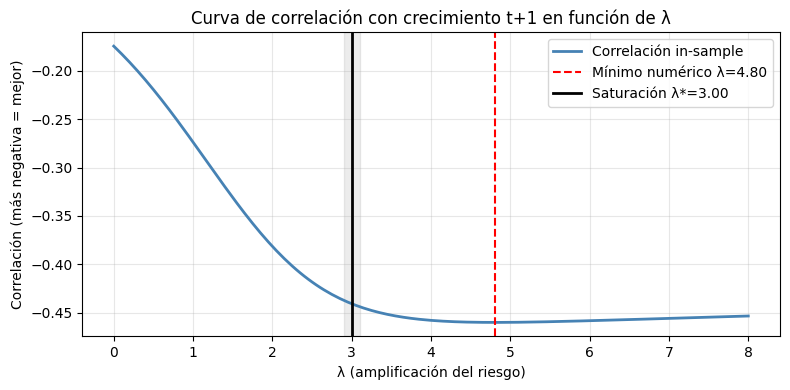

Figura guardada: figures/lambda_correlation_curve.pdf


In [44]:
# ==============================================================================
# DIAGNÓSTICO VISUAL · Curva de correlación y punto de saturación de λ
# ==============================================================================

plt.figure(figsize=(8,4))
plt.plot(corr_series.index, corr_series.values, lw=2, color='steelblue', label='Correlación in-sample')
plt.axvline(cont['lambda_star_cont'], color='red', linestyle='--', lw=1.5,
            label=f'Mínimo numérico λ={cont["lambda_star_cont"]:.2f}')
if 'lambda_best' in locals():
    plt.axvline(lambda_best, color='black', linestyle='-', lw=2,
                label=f'Saturación λ*={lambda_best:.2f}')

# Opcional: sombrear zona de saturación
if 'lambda_best' in locals():
    plt.axvspan(lambda_best-0.1, lambda_best+0.1, color='gray', alpha=0.15)

plt.title("Curva de correlación con crecimiento t+1 en función de λ")
plt.xlabel("λ (amplificación del riesgo)")
plt.ylabel("Correlación (más negativa = mejor)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/lambda_correlation_curve.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figura guardada: {figures_dir}/lambda_correlation_curve.pdf")


## FASE 6 · Diagnóstico visual del índice (ESD)

**Objetivo.** Mostrar, de forma compacta, cómo se relaciona el **índice ESD** con el **PIB** y qué lo impulsa.

**Qué hace esta celda.**
- Adapta las salidas de la Fase 6 (ESD) a un formato común de gráficos.
- Genera **dos figuras**:
  1) `vulnerability_analysis.pdf` — **overview 4 paneles**:
     - (i) **PIB real (log)** vs índice (eje derecho) y **umbral p75** ($\approx 0.36$).
     - (ii) **Crecimiento trimestral** vs índice.
     - (iii) **Dispersión** índice–crecimiento **sin COVID** (muestra la correlación).
     - (iv) **Descomposición**: z-scores de **Desequilibrio** y **Volatilidad**, con el índice en eje secundario.
  2) `covid_correlation_analysis.pdf` — **comparativa “con vs sin COVID”** (dos paneles) para evidenciar el cambio en la correlación.

**Cómo leer.**
- Índice **por encima de p75** ⇒ episodio de **vulnerabilidad elevada** (zonas sombreadas).
- La relación **índice–crecimiento** es **negativa** y suele **aclararse** al excluir COVID.
- La **descomposición** indica si pesan más el **desequilibrio** ($|\mathrm{ECT}|$) o la **volatilidad** ($\sigma_t$).

**Salidas.** Se guardan en `figures/`:
- `vulnerability_analysis.pdf`
- `covid_correlation_analysis.pdf`


C:\Users\Usuario\AppData\Local\Temp\ipykernel_64564\3451841044.py:167: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout(); plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.25)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_64564\3451841044.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(f"{figures_dir}/vulnerability_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_64564\3451841044.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(f"{figures_dir}/vulnerability_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')


✅ Figura guardada: vulnerability_analysis.pdf


C:\Users\Usuario\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


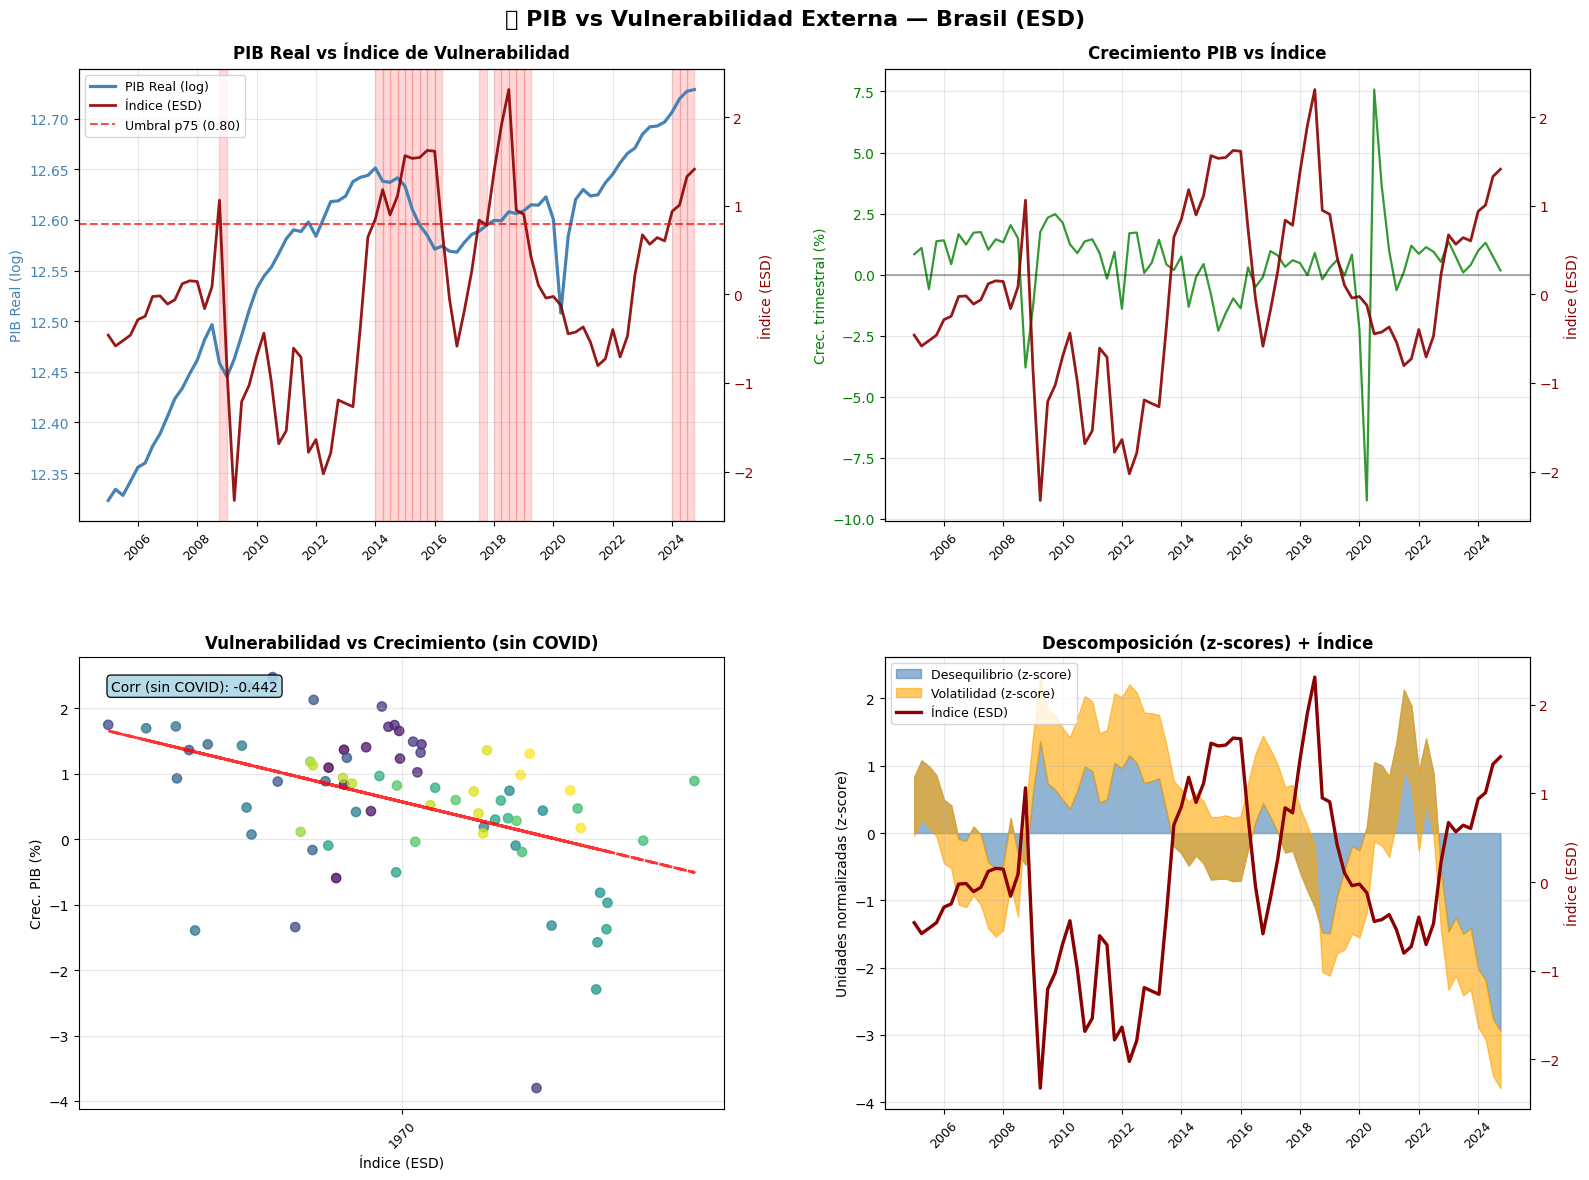

C:\Users\Usuario\AppData\Local\Temp\ipykernel_64564\3451841044.py:235: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_64564\3451841044.py:236: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.savefig(f"{figures_dir}/covid_correlation_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_64564\3451841044.py:236: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.savefig(f"{figures_dir}/covid_correlation_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')


✅ Figura guardada: covid_correlation_analysis.pdf


C:\Users\Usuario\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


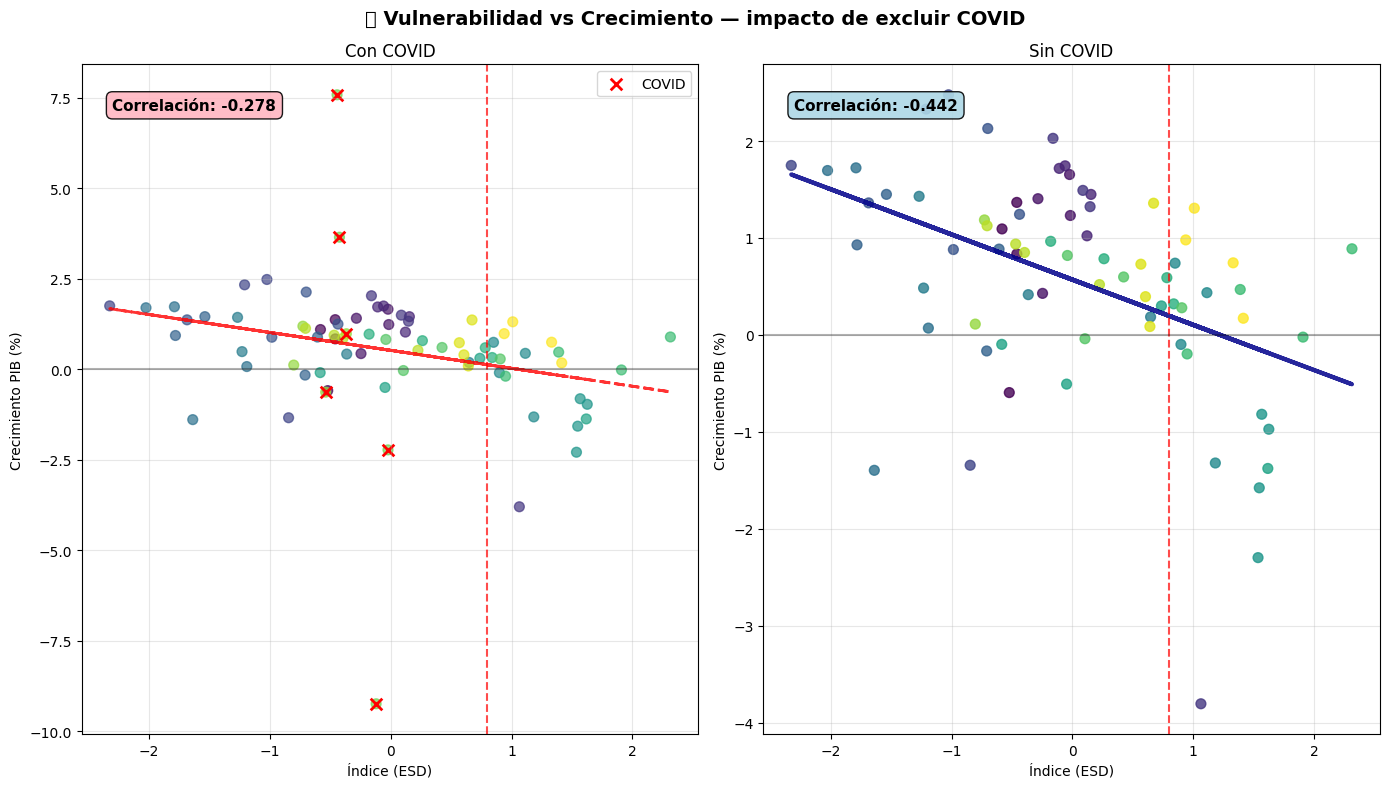

✅ Diagnóstico visual generado correctamente.


In [47]:
# ==============================================================================
# FASE 6 → DIAGNÓSTICO VISUAL (autocontenido para ESD)
#   Requiere que ya existan (de tu FASE 6 ESD):
#     - vuln_df  : DataFrame con columna 'indicator' (índice ESD)
#     - components: DataFrame con columnas ['Desequilibrio','Volatilidad'] (z-scores)
#     - df_aligned, figures_dir, final_model_results
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# ------------------ 1) Puente: Fase 6 -> estructura de visualización ------------------

def create_visualization_structure_from_phase6(vuln_df, components, threshold_percentile=75):
    """
    Adapta (vuln_df, components) a la estructura que consumen las funciones de plotting.
    No usa pesos; es 100% compatible con el enfoque ESD.
    """
    out = pd.DataFrame(index=vuln_df.index)

    # Índice de vulnerabilidad (nombre estándar que esperan los plots)
    if "indicator" in vuln_df.columns:
        idx = vuln_df["indicator"].rename("Vulnerability_Index_Optimized")
    else:
        # fallback si hubiera cambiado el nombre
        col_guess = [c for c in vuln_df.columns if "vulner" in c.lower() or "indic" in c.lower()]
        if not col_guess:
            raise ValueError("No se encontró la columna del indicador en vuln_df.")
        idx = vuln_df[col_guess[0]].rename("Vulnerability_Index_Optimized")

    out["Vulnerability_Index_Optimized"] = idx
    out["Vulnerability_Index"] = idx  # alias de compatibilidad

    # Componentes (z-scores creados en Fase 6)
    out["Desequilibrium_Component"] = components["Desequilibrio"].reindex(out.index)
    out["Volatility_Component"]     = components["Volatilidad"].reindex(out.index)

    # Umbral por percentil histórico
    vals = out["Vulnerability_Index_Optimized"].dropna().values
    thr = np.percentile(vals, threshold_percentile) if len(vals) else np.nan
    out["High_Vulnerability_Episode"] = out["Vulnerability_Index_Optimized"] > thr
    out["Vulnerability_Percentile"]   = out["Vulnerability_Index_Optimized"].rank(pct=True) * 100

    return {
        "vulnerability_data": out,
        "vulnerability_threshold": thr,
        "model_diagnostics": {
            "ect_coefficient": final_model_results.get("ect_coefficient", np.nan),
            "r_squared": final_model_results.get("r_squared", np.nan),
        }
    }
components = pd.DataFrame({
    'Desequilibrio': (gar_df['mu_ect'] - gar_df['mu_ect'].mean())/gar_df['mu_ect'].std(ddof=1),
    'Volatilidad'  : (gar_df['sigma_shock'] - gar_df['sigma_shock'].mean())/gar_df['sigma_shock'].std(ddof=1)
}, index=gar_df.index)

optimized_vulnerability_results = create_visualization_structure_from_phase6(
    vuln_df=vuln_df,
    components=components,
    threshold_percentile=75
)

# ------------------ 2) Plots: overview 4 paneles (versión ESD, sin pesos) --------------

def plot_gdp_vulnerability_analysis_esd(df_aligned, vulnerability_results, figsize=(16, 12), save_fig=False):
    """
    Análisis integral para el índice ESD (sin pesos). Panel 4 apila z-scores de
    Desequilibrio y Volatilidad, y superpone el índice ESD en eje secundario.
    """
    vd = vulnerability_results["vulnerability_data"]
    threshold = vulnerability_results["vulnerability_threshold"]

    # Series base
    vuln_series = vd["Vulnerability_Index_Optimized"]
    gdp_level   = df_aligned['log_gdp_brazil'].dropna()
    gdp_growth  = (df_aligned['log_gdp_brazil'].diff() * 100).dropna()

    # Alineación
    common_idx = vuln_series.index.intersection(gdp_level.index)

    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('📊 PIB vs Vulnerabilidad Externa — Brasil (ESD)',
                 fontsize=16, fontweight='bold', y=0.98)

    # ---- Panel 1: PIB (log) vs Índice ----
    ax1 = axes[0,0]
    ax1.plot(common_idx, gdp_level.loc[common_idx], color='steelblue', linewidth=2.3, label='PIB Real (log)')
    ax1.set_ylabel('PIB Real (log)', color='steelblue'); ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.grid(True, alpha=0.3); ax1.set_title('PIB Real vs Índice de Vulnerabilidad', fontweight='bold', pad=8)

    ax1b = ax1.twinx()
    ax1b.plot(vd.index, vuln_series, color='darkred', linewidth=2, alpha=0.9, label='Índice (ESD)')
    if np.isfinite(threshold):
        ax1b.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, label=f'Umbral p75 ({threshold:.2f})')
    ax1b.set_ylabel('Índice (ESD)', color='darkred'); ax1b.tick_params(axis='y', labelcolor='darkred')

    # Sombrear episodios altos
    if 'High_Vulnerability_Episode' in vd.columns:
        high = vd['High_Vulnerability_Episode']
        for i in range(len(high)-1):
            if bool(high.iloc[i]):
                ax1.axvspan(vd.index[i], vd.index[i+1], color='red', alpha=0.15)

    # Leyenda combinada
    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1+l2, lab1+lab2, loc='upper left', fontsize=9)

    # ---- Panel 2: Crecimiento vs Índice ----
    ax2 = axes[0,1]
    growth_al = gdp_growth.reindex(vd.index)
    ax2.plot(vd.index, growth_al, color='green', linewidth=1.6, alpha=0.8, label='Crecimiento PIB (%)')
    ax2.axhline(0, color='black', alpha=0.3); ax2.grid(True, alpha=0.3)
    ax2.set_title('Crecimiento PIB vs Índice', fontweight='bold', pad=8)
    ax2.set_ylabel('Crec. trimestral (%)', color='green'); ax2.tick_params(axis='y', labelcolor='green')

    ax2b = ax2.twinx()
    ax2b.plot(vd.index, vuln_series, color='darkred', linewidth=2, alpha=0.9, label='Índice (ESD)')
    ax2b.set_ylabel('Índice (ESD)', color='darkred'); ax2b.tick_params(axis='y', labelcolor='darkred')

    # ---- Panel 3: Scatter sin COVID ----
    ax3 = axes[1,0]
    df_sc = pd.DataFrame({'v': vuln_series, 'g': growth_al}).dropna()
    covid_mask = (df_sc.index.year == 2020) | ((df_sc.index.year == 2021) & (df_sc.index.quarter <= 2))
    clean = df_sc.loc[~covid_mask]
    ax3.scatter(clean['v'], clean['g'], c=clean.index.year, cmap='viridis', alpha=0.75, s=45)
    if len(clean) > 5:
        z = np.polyfit(clean['v'], clean['g'], 1); p = np.poly1d(z)
        ax3.plot(clean['v'], p(clean['v']), 'r--', lw=2, alpha=0.8, label='Tendencia (sin COVID)')
        ax3.text(0.05, 0.95, f"Corr (sin COVID): {clean['v'].corr(clean['g']):.3f}",
                 transform=ax3.transAxes, ha='left', va='top',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9))
    ax3.grid(True, alpha=0.3); ax3.set_xlabel('Índice (ESD)'); ax3.set_ylabel('Crec. PIB (%)')
    ax3.set_title('Vulnerabilidad vs Crecimiento (sin COVID)', fontweight='bold')

    # ---- Panel 4: Descomposición (z-scores) + Índice en eje secundario ----
    ax4 = axes[1,1]
    dates = vd.index
    deseq = vd['Desequilibrium_Component']
    volat = vd['Volatility_Component']

    base = np.zeros(len(dates))
    ax4.fill_between(dates, base, base + deseq, alpha=0.6, color='steelblue', label='Desequilibrio (z-score)')
    ax4.fill_between(dates, base + deseq, base + deseq + volat, alpha=0.6, color='orange', label='Volatilidad (z-score)')
    ax4.set_ylabel('Unidades normalizadas (z-score)')
    ax4.grid(True, alpha=0.3); ax4.set_title('Descomposición (z-scores) + Índice', fontweight='bold')

    ax4b = ax4.twinx()
    ax4b.plot(dates, vuln_series, color='darkred', lw=2.4, label='Índice (ESD)')
    ax4b.set_ylabel('Índice (ESD)', color='darkred'); ax4b.tick_params(axis='y', labelcolor='darkred')

    # Leyenda del panel 4 (combinar ambas)
    l1, lab1 = ax4.get_legend_handles_labels()
    l2, lab2 = ax4b.get_legend_handles_labels()
    ax4.legend(l1 + l2, lab1 + lab2, loc='upper left', fontsize=9)

    # Formato fechas
    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        if hasattr(ax, 'xaxis'):
            ax.xaxis.set_major_locator(YearLocator(2))
            ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    plt.tight_layout(); plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.25)

    if save_fig:
        plt.savefig(f"{figures_dir}/vulnerability_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
        print("✅ Figura guardada: vulnerability_analysis.pdf")

    plt.show()

# ------------------ 3) Plot de correlación COVID vs sin COVID --------------------------

def plot_vulnerability_correlation_analysis(df_aligned, vulnerability_results, figsize=(14, 8)):
    """
    Comparativa de correlación Índice–Crecimiento con y sin COVID. Guarda PDF.
    """
    vd = vulnerability_results['vulnerability_data']
    threshold = vulnerability_results['vulnerability_threshold']
    vuln_col = 'Vulnerability_Index_Optimized' if 'Vulnerability_Index_Optimized' in vd.columns else 'Vulnerability_Index'

    gdp_growth = (df_aligned['log_gdp_brazil'].diff() * 100).dropna()
    analysis = pd.DataFrame({
        'vulnerability': vd[vuln_col],
        'gdp_growth': gdp_growth.reindex(vd.index),
        'year': vd.index.year,
        'quarter': vd.index.quarter
    }).dropna()

    covid_mask = (analysis['year'] == 2020) | ((analysis['year'] == 2021) & (analysis['quarter'] <= 2))
    clean = analysis.loc[~covid_mask]
    covid = analysis.loc[covid_mask]

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('🔍 Vulnerabilidad vs Crecimiento — impacto de excluir COVID', fontsize=14, fontweight='bold')

    # Left: con COVID
    ax1 = axes[0]
    ax1.scatter(analysis['vulnerability'], analysis['gdp_growth'], c=analysis['year'], cmap='viridis', alpha=0.7, s=50)
    if len(analysis) > 5:
        z1 = np.polyfit(analysis['vulnerability'], analysis['gdp_growth'], 1); p1 = np.poly1d(z1)
        ax1.plot(analysis['vulnerability'], p1(analysis['vulnerability']), "r--", alpha=0.8, lw=2)
        corr1 = analysis['vulnerability'].corr(analysis['gdp_growth'])
        ax1.text(0.05, 0.95, f'Correlación: {corr1:.3f}', transform=ax1.transAxes,
                 fontsize=11, weight='bold', va='top', bbox=dict(boxstyle="round,pad=0.4", facecolor="lightpink", alpha=0.9))
    if np.isfinite(threshold):
        ax1.axvline(threshold, color='red', ls='--', alpha=0.7)
    ax1.axhline(0, color='black', alpha=0.3)
    if len(covid) > 0:
        ax1.scatter(covid['vulnerability'], covid['gdp_growth'], color='red', marker='x', s=70, lw=2, label='COVID')
        ax1.legend()
    ax1.set_xlabel('Índice (ESD)'); ax1.set_ylabel('Crecimiento PIB (%)'); ax1.grid(True, alpha=0.3)
    ax1.set_title('Con COVID')

    # Right: sin COVID
    ax2 = axes[1]
    if len(clean) > 0:
        ax2.scatter(clean['vulnerability'], clean['gdp_growth'], c=clean['year'], cmap='viridis', alpha=0.8, s=50)
        if len(clean) > 5:
            z2 = np.polyfit(clean['vulnerability'], clean['gdp_growth'], 1); p2 = np.poly1d(z2)
            ax2.plot(clean['vulnerability'], p2(clean['vulnerability']), "darkblue", lw=3, alpha=0.85)
            corr2 = clean['vulnerability'].corr(clean['gdp_growth'])
            ax2.text(0.05, 0.95, f'Correlación: {corr2:.3f}', transform=ax2.transAxes,
                     fontsize=11, weight='bold', va='top',
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.9))
    if np.isfinite(threshold):
        ax2.axvline(threshold, color='red', ls='--', alpha=0.7)
    ax2.axhline(0, color='black', alpha=0.3)
    ax2.set_xlabel('Índice (ESD)'); ax2.set_ylabel('Crecimiento PIB (%)'); ax2.grid(True, alpha=0.3)
    ax2.set_title('Sin COVID')

    plt.tight_layout()
    plt.savefig(f"{figures_dir}/covid_correlation_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
    print("✅ Figura guardada: covid_correlation_analysis.pdf")
    plt.show()

# ------------------ 4) Ejecutar y guardar figuras --------------------------------------

plot_gdp_vulnerability_analysis_esd(
    df_aligned,
    optimized_vulnerability_results,
    save_fig=True
)

covid_analysis = plot_vulnerability_correlation_analysis(
    df_aligned,
    optimized_vulnerability_results
)

print("✅ Diagnóstico visual generado correctamente.")


In [32]:
print("Resumen mu_ect:")
print(gar_df['mu_ect'].describe())

print("\nResumen sigma_shock:")
print(gar_df['sigma_shock'].describe())

print("\nResumen índice (Vulnerability_Index_Optimized):")
print(gar_df['Vulnerability_Index_Optimized'].describe())


Resumen mu_ect:
count    81.000000
mean     -0.000197
std       0.002295
min      -0.005575
25%      -0.001797
50%      -0.000283
75%       0.000826
max       0.004985
Name: mu_ect, dtype: float64

Resumen sigma_shock:
count    81.000000
mean      0.005597
std       0.001952
min       0.003125
25%       0.003651
50%       0.004705
75%       0.007507
max       0.007816
Name: sigma_shock, dtype: float64

Resumen índice (Vulnerability_Index_Optimized):
count    8.100000e+01
mean     1.014278e-16
std      1.000000e+00
min     -2.304372e+00
25%     -3.272388e-01
50%     -4.813182e-02
75%      6.367916e-01
max      2.523700e+00
Name: Vulnerability_Index_Optimized, dtype: float64


## Fase 6 · Atribución dinámica de la incertidumbre del índice ESD

Esta sección analiza **qué factores generan mayor incertidumbre en la vulnerabilidad macroeconómica**.  
El objetivo no es solo identificar los niveles de desequilibrio o riesgo, sino **entender en cada momento qué canal (estructural o financiero) domina la dinámica del índice ESD**.

#### 1. Variaciones del desequilibrio estructural (Δμₜ)
El primer gráfico descompone la **variación trimestral del desequilibrio (μₜ)** en sus fuentes:
- Cada color representa la contribución de una variable de cointegración (por ejemplo, términos de intercambio, tasas de EE. UU., constante del equilibrio).
- La línea negra indica la variación total Δμₜ.
- Picos positivos o negativos muestran qué componente está **desestabilizando o reequilibrando** la economía en ese trimestre.

Este gráfico permite distinguir entre periodos de **ajuste estructural suave** (μ estable) y fases donde una variable concreta rompe el equilibrio de largo plazo.

#### 2. Contribución de los shocks a la volatilidad (σₜ²)
El segundo gráfico muestra cómo evoluciona la composición del **riesgo de corto plazo**:
- Cada línea representa el peso de un tipo de shock (comercial, financiero, riesgo global, demanda externa) en la varianza total σₜ².
- Los valores son shares porcentuales en una media móvil de cuatro trimestres.

Así puede verse si el riesgo externo proviene principalmente de:
- **Factores financieros** (spreads, tasas de EE. UU.),
- **Choques reales** (términos de intercambio),
- o **perturbaciones de demanda global** (producción del G7).

#### 3. Dominancia relativa de incertidumbre (|μₜ| vs. σₜ)
El tercer gráfico combina ambas dimensiones:
- La línea azul representa la magnitud normalizada del desequilibrio estructural |μₜ|.
- La línea naranja discontinua representa el riesgo externo σₜ.
- Las áreas sombreadas indican qué canal domina:
  - Azul → vulnerabilidad **estructural** (predomina el desequilibrio interno),
  - Naranja → vulnerabilidad **financiera** (predomina el riesgo global).

Este diagnóstico permite responder a la pregunta clave:
> “¿La vulnerabilidad de la economía brasileña proviene más de desequilibrios internos o de condiciones externas?”

En conjunto, los tres gráficos proporcionan una **lectura dinámica y atribuida del riesgo**, mostrando cómo cambian las fuentes de vulnerabilidad en el tiempo.


In [26]:
# ==============================================================================
# FASE 6 · ATRIBUCIÓN DEL ÍNDICE (μ/σ) A VARIABLES Y SHOCKS
# Requiere: df_aligned, final_model_results, vuln_df, components, g, shock_cols, win
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# ---------------------------------------------------------------------------
# A) DESEQUILIBRIO μₜ: descomposición por variables estructurales y lags del ECT
# ---------------------------------------------------------------------------

def mu_decomposition_by_variable(df, final_model_results, level_vars=None, ect_name='ECT'):
    """
    Descompone el desequilibrio μₜ en:
      - μ_total: suma ponderada de los ECT rezagados (α_L * ECT_{t-L})
      - μ_by_var: contribución de cada variable de cointegración y constante
      - μ_by_lag: contribución de cada lag del ECT

    μₜ mide el componente estructural del desequilibrio (corrección hacia equilibrio).
    """
    ect = final_model_results['ect'].reindex(df.index)
    params = final_model_results['model'].params
    beta = final_model_results['cointegration_model'].params

    # Extrae los coeficientes α_L (velocidades de ajuste)
    alphas = {}
    for name, val in params.items():
        if ect_name.lower() in name.lower():
            import re
            m = re.search(r'(?:_?L|lag)\s*(\d+)', name, flags=re.IGNORECASE)
            L = int(m.group(1)) if m else 1
            alphas[L] = float(val)
    if not alphas:
        raise ValueError("No se encontraron coeficientes α_L del ECT en el modelo.")

    # Variables de cointegración
    if level_vars is None:
        level_vars = [v for v in beta.index if v.lower() not in ('const', 'intercept')]

    # μ total: suma α_L * ECT_{t-L}
    mu_total = pd.Series(0.0, index=df.index, name='μ_total')
    for L, aL in alphas.items():
        mu_total += aL * ect.shift(L)

    # Contribución por variable (lineal): α_L * β_v * z_{v,t-L}
    mu_by_var = pd.DataFrame(0.0, index=df.index, columns=level_vars + ['const'])
    b0 = float(beta.get('const', beta.get('Intercept', 0.0)))
    for L, aL in alphas.items():
        if b0 != 0.0:
            mu_by_var['const'] += aL * b0
        for v in level_vars:
            mu_by_var[v] += aL * float(beta[v]) * df[v].shift(L)

    # Contribución por lag del ECT
    mu_by_lag = pd.DataFrame({f'ECT_L{L}': aL * ect.shift(L) for L, aL in alphas.items()}, index=df.index)

    return mu_total, mu_by_var, mu_by_lag

mu_total, mu_by_var, mu_by_lag = mu_decomposition_by_variable(df_aligned, final_model_results)

# ---------------------------------------------------------------------------
# B) RIESGO σₜ²: contribución de cada shock a la volatilidad (tipo Shapley)
# ---------------------------------------------------------------------------

def sigma_and_var_contribs(df, shock_cols, g, window=40, min_periods=None):
    """
    Calcula σₜ y sus contribuciones por shock.
    σₜ² = g' Σ_t g  → contribución_i = g_i * (Σ_t g)_i
    Devuelve:
      - sigma: Serie σₜ
      - var_contribs: DataFrame con contribuciones absolutas
      - var_shares: shares relativos c_i,t / σₜ²
    """
    if min_periods is None:
        min_periods = max(20, len(shock_cols)*3)

    sigma = pd.Series(np.nan, index=df.index, name='σ_shock')
    var_contribs = pd.DataFrame(np.nan, index=df.index, columns=shock_cols)

    for t in range(len(df)):
        start = max(0, t-window+1)
        sample = df.iloc[start:t+1][shock_cols].dropna()
        if len(sample) >= min_periods:
            S = sample.cov().values
            gvec = np.asarray(g, dtype=float).reshape(-1)
            sigma2 = float(gvec @ S @ gvec)
            sigma.iloc[t] = np.sqrt(max(0.0, sigma2))
            var_contribs.iloc[t] = gvec * (S @ gvec)  # contribuciones absolutas
    var_shares = var_contribs.div((sigma**2), axis=0)
    return sigma, var_contribs, var_shares

sigma_chk, var_contribs, var_shares = sigma_and_var_contribs(df=df_aligned, shock_cols=shock_cols, g=g, window=win)

'''
# ---------------------------------------------------------------------------
# C) Diagnósticos numéricos: medias y últimos valores
# ---------------------------------------------------------------------------

mu_var_stats = mu_by_var.agg(['mean', 'quantile', 'last']).T
mu_var_stats['quantile'] = mu_by_var.quantile(0.95)
mu_var_stats['last'] = mu_by_var.iloc[-1]
mu_var_stats = mu_var_stats.sort_values('mean', ascending=False)

var_shares_stats = pd.DataFrame({
    'mean_share': var_shares.mean(),
    'last_share': var_shares.iloc[-1]
}).sort_values('mean_share', ascending=False)

print("=== Atribución de μₜ por variables de cointegración ===")
print(mu_var_stats.round(4).to_string())
print("\n=== Atribución de σₜ² por shocks ===")
print((100 * var_shares_stats).round(1).to_string())

# ---------------------------------------------------------------------------
# D) Visualización integrada: qué domina la incertidumbre
# ---------------------------------------------------------------------------

# --- (1) μₜ por variable (stacked area)
common = mu_by_var.index.intersection(mu_total.index)
plt.figure(figsize=(12,4))
base = np.zeros(len(common))
for v in mu_by_var.columns:
    vals = mu_by_var.loc[common, v].values
    plt.fill_between(common, base, base + vals, alpha=0.6, label=v)
    base += vals
plt.plot(common, mu_total.loc[common], lw=2.2, color='black', label='μ total')
plt.title('Atribución del desequilibrio estructural (μₜ)')
plt.xlabel('Fecha'); plt.ylabel('Contribución')
plt.legend(loc='upper left', ncol=3, fontsize=9); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/mu_decomposition.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- (2) σₜ² por shock (shares %)
shares_smooth = var_shares.rolling(4, min_periods=1).mean() * 100
plt.figure(figsize=(12,4))
for sc in shock_cols:
    plt.plot(shares_smooth.index, shares_smooth[sc], lw=2, label=sc)
plt.title('Contribución de cada shock a la volatilidad total σₜ²')
plt.xlabel('Fecha'); plt.ylabel('% de σₜ²')
plt.legend(loc='upper left'); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/sigma_shares_by_shock.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- (3) Composición de la incertidumbre total: |μₜ| vs σₜ
# Idea: visualizar quién "domina" la vulnerabilidad (desequilibrio o riesgo)
plt.figure(figsize=(10,5))
plt.plot(df_aligned.index, mu_total.abs()/mu_total.abs().max(), lw=2, label='Desequilibrio |μₜ| (norm.)')
plt.plot(df_aligned.index, sigma_chk/sigma_chk.max(), lw=2, label='Riesgo σₜ (norm.)', linestyle='--')
plt.title('Peso relativo de desequilibrio estructural y riesgo externo en la vulnerabilidad')
plt.xlabel('Fecha'); plt.ylabel('Escala normalizada')
plt.legend(); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/uncertainty_composition.pdf', dpi=300, bbox_inches='tight'); plt.show()

'''


KeyError: 'cointegration_model'

In [27]:
# ==============================================================================
# FASE 6bis · ATRIBUCIÓN DINÁMICA DEL ÍNDICE — Quién aporta incertidumbre
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# --- 1. Cambios trimestrales de μₜ por variable (dinámica del desequilibrio)
mu_by_var_diff = mu_by_var.diff()  # variación marginal
mu_total_diff = mu_total.diff()

plt.figure(figsize=(12,4))
base = np.zeros(len(mu_by_var_diff))
for v in mu_by_var_diff.columns:
    vals = mu_by_var_diff[v].fillna(0).values
    plt.fill_between(mu_by_var_diff.index, base, base + vals, alpha=0.6, label=v)
    base += vals
plt.plot(mu_by_var_diff.index, mu_total_diff, lw=2.2, color='black', label='Δμ total')
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title('Variación trimestral del desequilibrio estructural (Δμₜ)')
plt.xlabel('Fecha'); plt.ylabel('Contribución marginal')
plt.legend(loc='upper left', ncol=3, fontsize=9)
plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/mu_dynamic_contribs.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- 2. Riesgo σₜ²: shares dinámicos normalizados
shares_dyn = var_shares.rolling(4, min_periods=1).mean() * 100
shares_dyn = shares_dyn.clip(lower=0, upper=100)
plt.figure(figsize=(12,4))
for sc in shock_cols:
    plt.plot(shares_dyn.index, shares_dyn[sc], lw=2, label=sc)
plt.title('Contribución dinámica de cada shock a la volatilidad total σₜ²')
plt.xlabel('Fecha'); plt.ylabel('% de σₜ² (media móvil 4)')
plt.legend(loc='upper left', ncol=4, fontsize=9); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/sigma_dynamic_shares.pdf', dpi=300, bbox_inches='tight'); plt.show()

# --- 3. Índice de "incertidumbre relativa": qué canal domina (μ vs σ)
# Normaliza ambos componentes
mu_norm = mu_total.abs() / mu_total.abs().max()
sigma_norm = sigma_chk / sigma_chk.max()
dominance = mu_norm - sigma_norm  # >0: domina desequilibrio; <0: domina riesgo

plt.figure(figsize=(10,5))
plt.fill_between(dominance.index, 0, dominance, where=dominance>0, color='tab:blue', alpha=0.3, label='Dominio estructural (μ)')
plt.fill_between(dominance.index, 0, dominance, where=dominance<0, color='tab:orange', alpha=0.3, label='Dominio financiero (σ)')
plt.plot(mu_norm.index, mu_norm, lw=2, color='tab:blue', label='|μₜ| (norm.)')
plt.plot(sigma_norm.index, sigma_norm, lw=2, color='tab:orange', linestyle='--', label='σₜ (norm.)')
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title('Dominio relativo de incertidumbre: desequilibrio estructural vs. riesgo externo')
plt.xlabel('Fecha'); plt.ylabel('Escala normalizada')
plt.legend(loc='upper left'); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/uncertainty_dominance.pdf', dpi=300, bbox_inches='tight'); plt.show()


NameError: name 'mu_by_var' is not defined

#### Dynamic Attribution of Vulnerability Components

The dynamic decomposition of the ESD indicator provides a time-varying view of the relative contribution of structural and financial factors to Brazil’s macroeconomic vulnerability.

The structural component (μₜ) captures the equilibrium correction process derived from the error-correction model.  
Its quarterly variations (Δμₜ) reveal which long-term relationships — such as terms of trade, U.S. interest rates or the constant of the cointegrating vector — drive deviations from equilibrium in each period. Positive or negative peaks in Δμₜ indicate moments of structural destabilization or adjustment, respectively.

The risk component (σₜ²) measures external volatility derived from the covariance structure of shocks.  
Its decomposition by source (trade, financial, or global-demand shocks) shows which channels dominate the short-term uncertainty at each point in time. The dynamic shares of σₜ² highlight whether vulnerability arises from financial tightening, commodity shocks or external demand conditions.

Finally, the relative dominance between |μₜ| and σₜ identifies whether vulnerability is primarily **structural** or **financial**.  
Periods where |μₜ| exceeds σₜ denote vulnerability driven by internal disequilibria, whereas σₜ > |μₜ| reflects exposure to external risk and global volatility.

Together, these decompositions provide a granular understanding of the evolving balance between internal adjustment pressures and external shocks, clarifying which mechanisms contribute most to Brazil’s macro-financial fragility over time.
